# Traffic Violation Classifications #
-----
Name: Aieshma Khadka 

Rollno: KCE081BCT006

-----


## *Problem Statement*
In many regions, monitoring and managing traffic violations is a challenging task because violations occur due to multiple factors such as driver age, vehicle type, speed, alcohol level, road condition, weather condition, and previous violation history. Traditional traffic monitoring systems primarily rely on manual recording and rule-based identification, which may not efficiently analyze patterns across large volumes of data.

This problem can be addressed by analyzing traffic violation data using Exploratory Data Analysis (EDA) and machine learning techniques. By studying the dataset, we can understand the structure of the data, identify missing values and outliers, analyze the distribution of various features, and explore the relationship between driver, vehicle, and environmental factors with different types of traffic violations.

The insights obtained from this analysis can help authorities and organizations understand which factors contribute most significantly to specific types of violations. This supports better decision-making in areas such as traffic law enforcement, awareness programs, safety policy development, and preventive strategies. Additionally, building a classification model can help predict the type of violation based on given input features, improving the efficiency of traffic monitoring systems.

-----

## *Objective* 
To classify traffic violations based on the vehicle and drivers data.

-----


## DATASET SUMMARY

The Traffic Violations Dataset (Traffic_Sample.csv) contains structured records of traffic stops and violations. The dataset provides information related to traffic offenses, driver demographics, vehicle details, incident conditions, and enforcement outcomes. It can be used for traffic pattern analysis, violation classification, accident analysis, and law enforcement decision-making studies.

- The dataset contains multiple records of traffic violations.  
- Each row represents a single traffic stop incident.  
- The dataset includes categorical, numerical, and date/time features.

---

## Dataset Features

| Feature | Description |
|---|---|
| Date_Of_Stop | Date when the traffic stop occurred |
| Time_Of_Stop | Time at which the stop occurred |
| Agency | Law enforcement agency responsible for the stop |
| SubAgency | Sub-division of the law enforcement agency |
| Description | Description of the traffic violation |
| Location | Street or area where the violation occurred |
| Latitude | Geographic latitude of the stop location |
| Longitude | Geographic longitude of the stop location |
| Accident | Indicates whether the violation involved an accident (Yes/No) |
| Belts | Indicates whether a seatbelt violation was involved |
| Personal_Injury | Indicates if personal injury occurred |
| Property_Damage | Indicates if property damage occurred |
| Fatal | Indicates if the incident involved a fatality |
| Commercial_License | Whether the driver holds a commercial license |
| Commercial_Vehicle | Indicates if the vehicle was commercial |
| Alcohol | Indicates alcohol involvement in the violation |
| Work_Zone | Whether the violation occurred in a work zone area |
| State | State of vehicle registration |
| Vehicle_Type | Type of vehicle (Car, Truck, Motorcycle, etc.) |
| Year | Manufacturing year of the vehicle |
| Make | Manufacturer of the vehicle |
| Model | Vehicle model |
| Color | Vehicle color |
| Violation_Type | Category of violation (Speeding, Equipment, Registration, etc.) |
| Charge | Legal charge code associated with the violation |
| Driver_Race | Race category of the driver |
| Driver_Gender | Gender of the driver |
| Driver_City | City of residence of the driver |
| Driver_State | State of residence of the driver |
| Arrest_Type | Outcome of the stop (Arrest, Citation, Warning, etc.) |

---

## Feature Classification

### Qualitative Features

| Feature |
|---|
| Agency |
| SubAgency |
| Description |
| Location |
| Accident |
| Belts |
| Personal_Injury |
| Property_Damage |
| Fatal |
| Commercial_License |
| Commercial_Vehicle |
| Alcohol |
| Work_Zone |
| State |
| Vehicle_Type |
| Make |
| Model |
| Color |
| Violation_Type |
| Charge |
| Driver_Race |
| Driver_Gender |
| Driver_City |
| Driver_State |
| Arrest_Type |

---

### Quantitative Features

| Feature |
|---|
| Latitude |
| Longitude |
| Year |

---

### Date/Time Features

| Feature |
|---|
| Date_Of_Stop |
| Time_Of_Stop |

---

## Target Feature (For Analysis)

| Possible Target Variable | Description |
|---|---|
| Violation_Type | Categorical variable used for classification tasks. Class imbalance may exist and will be examined during EDA. |

---

## Initial Data Preprocessing Decisions

| Feature | Keep/Drop | Reason |
|---|---|---|
| Latitude & Longitude | Keep | Useful for geographic and spatial analysis |
| Date_Of_Stop | Transform | Extract year, month, and day for trend analysis |
| Time_Of_Stop | Transform | Extract hour for time-based pattern analysis |
| Location | Clean/Transform | Requires text cleaning or encoding |
| Driver_City | Optional | High cardinality; may require encoding techniques |

-------

### EDA (Exploratory Data Analysis)

In Model Training Step,

First we need to Understand the dataset what problems and errors does it contains then we must handel the error present in  data by applying diferent approaches.

---

### Importing required libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt







- Pandas is required for reading, modifying and analyzing the data.
- Numpy is necessary for Efficient and faster mathematical calculations.
- Matplotlib helps to create basis graphs and charts.(Pyplot is the module of matplotlib it is the simple plotting function)

-------

In [2]:
df=pd.read_csv("Traffic_Sample.csv")

The dataset is loaded from the csv file using the pandas read_csv() function.

------


In [3]:
df.head()

,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,Belts,...,Charge,Article,Contributed To Accident,Race,Gender,Driver City,Driver State,DL State,Arrest Type,Geolocation
0,11/25/2016,23:09:00,MCP,"4th district, Wheaton",DRIVER WHEN TURNING LEFT FAIL TO YIELD RIGHT O...,REEDIE DR. @ GEORGIA AVE.,39.038140,-77.050898,No,No,...,21-402(a),Transportation Article,No,BLACK,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(39.03814, -77.0508983333333)"
1,11/25/2016,23:01:00,MCP,"4th district, Wheaton",FAILURE OF DR. TO SLOW TO REASONABLE & PRUDENT...,UNIVERSITY BLVD/KING GEORGE DR,39.042022,-77.051628,No,No,...,21-405(e2),Transportation Article,No,WHITE,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(39.0420216666667, -77.0516283333333)"
2,11/23/2016,22:31:00,MCP,"5th district, Germantown",FAILURE TO DISPLAY TWO LIGHTED FRONT LAMPS WHE...,FREDERICK RD @ HENDERSON CORNER RD,39.203110,-77.245487,No,No,...,22-226(a),Transportation Article,No,WHITE,F,CLARKSBURG,MD,MD,A - Marked Patrol,"(39.20311, -77.2454866666667)"
3,11/27/2016,13:09:00,MCP,"6th district, Gaithersburg / Montgomery Village",DRIVER WHEN TURNING LEFT FAIL TO YIELD RIGHT O...,WATKINS MILL / RUSSELL AVE,39.160003,-77.217207,No,No,...,21-402(a),Transportation Article,No,BLACK,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.1600033333333, -77.2172066666667)"
4,11/23/2016,22:43:00,MCP,"5th district, Germantown",DRIVER FAIL TO STOP AT RED TRAFFIC SIGNAL BEFO...,FREDERICK RD @ MIDDLEBROOK RD,39.178932,-77.240963,No,No,...,21-202(i1),Transportation Article,No,OTHER,F,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.1789316666667, -77.2409633333333)"


Here df.head() is the pandas function to display the first five rows of the dataset defaulty for the quick inspection of the data structure and feature names and sample values.

-------

In [5]:
df.shape


(5000, 35)

Here df.shape is the pandas function to check the dimension of the dataset.

-------


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date Of Stop             5000 non-null   str    
 1   Time Of Stop             5000 non-null   str    
 2   Agency                   5000 non-null   str    
 3   SubAgency                5000 non-null   str    
 4   Description              5000 non-null   str    
 5   Location                 5000 non-null   str    
 6   Latitude                 4538 non-null   float64
 7   Longitude                4538 non-null   float64
 8   Accident                 5000 non-null   str    
 9   Belts                    5000 non-null   str    
 10  Personal Injury          5000 non-null   str    
 11  Property Damage          5000 non-null   str    
 12  Fatal                    5000 non-null   str    
 13  Commercial License       5000 non-null   str    
 14  HAZMAT                   5000 non-n

Here df.info() is the pandas function to get the concise summary of the dataset.

-------

In [7]:
df.describe(include="all")


,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,Belts,...,Charge,Article,Contributed To Accident,Race,Gender,Driver City,Driver State,DL State,Arrest Type,Geolocation
count,5000,5000,5000,5000,5000,5000,4538.000000,4538.000000,5000,5000,...,5000,5000,5000,5000,5000,4998,5000,4985,5000,4538
unique,863,1188,1,7,523,2685,NaN,NaN,1,2,...,238,2,2,6,2,288,30,39,15,2943
top,11/23/2016,00:39:00,MCP,"4th district, Wheaton",DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC...,GEORGIA AVE @ URBANA DR,NaN,NaN,No,No,...,21-801.1,Transportation Article,No,BLACK,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(39.1840266666667, -77.262855)"
freq,400,24,5000,1417,404,37,NaN,NaN,5000,4854,...,432,4991,4863,1704,3452,1330,4549,4340,4472,16
mean,NaN,NaN,NaN,NaN,NaN,NaN,39.081648,-77.108867,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.066349,0.093887,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,38.945270,-77.510903,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,39.033878,-77.193736,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,39.071092,-77.087270,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,39.133026,-77.040701,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Here df.describe() is used to generate the descriptiv stastics of numerical or categorical features.

--------

In [8]:
df.nunique()


Date Of Stop                863
Time Of Stop               1188
Agency                        1
SubAgency                     7
Description                 523
Location                   2685
Latitude                   2917
Longitude                  2919
Accident                      1
Belts                         2
Personal Injury               2
Property Damage               2
Fatal                         2
Commercial License            2
HAZMAT                        1
Commercial Vehicle            2
Alcohol                       2
Work Zone                     1
State                        36
VehicleType                  13
Year                         36
Make                        171
Model                       664
Color                        24
Violation Type                2
Charge                      238
Article                       2
Contributed To Accident       2
Race                          6
Gender                        2
Driver City                 288
Driver S

df.nunique() is used to count the number of unique values in each colum of datasets.

------

In [9]:
df.columns

Index(['Date Of Stop', 'Time Of Stop', 'Agency', 'SubAgency', 'Description',
       'Location', 'Latitude', 'Longitude', 'Accident', 'Belts',
       'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License',
       'HAZMAT', 'Commercial Vehicle', 'Alcohol', 'Work Zone', 'State',
       'VehicleType', 'Year', 'Make', 'Model', 'Color', 'Violation Type',
       'Charge', 'Article', 'Contributed To Accident', 'Race', 'Gender',
       'Driver City', 'Driver State', 'DL State', 'Arrest Type',
       'Geolocation'],
      dtype='str')

---

## Step 1: Missing Data Checking and Handling

Missing data is a common issue in real-world datasets. Before training any machine learning model, it is important to identify and handle missing values to avoid errors and biased predictions.

---

### 1.1 Identify Missing Values

`df.isnull().sum()` returns the count of missing (NaN/null) values for each column.  
`isnull()` is a pandas method that returns a boolean DataFrame where `True` indicates a missing value.  
`.sum()` then counts the `True` values per column.

We also calculate the **percentage** of missing values to understand the severity.

In [3]:
# Count missing values per column
missing_counts = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

# Combine into a single DataFrame for clear display
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percent
})

# Filter to show only columns that have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df.sort_values(by='Missing Count', ascending=False)

,Missing Count,Missing Percentage (%)
Latitude,462,9.24
Longitude,462,9.24
Geolocation,462,9.24
Color,44,0.88
Year,27,0.54
DL State,15,0.30
Driver City,2,0.04


### 1.2 Visualize Missing Values

A bar chart helps to visually compare the extent of missing data across columns at a glance.

`plt.bar()` creates a vertical bar chart. `plt.xticks(rotation=45)` rotates x-axis labels for readability.

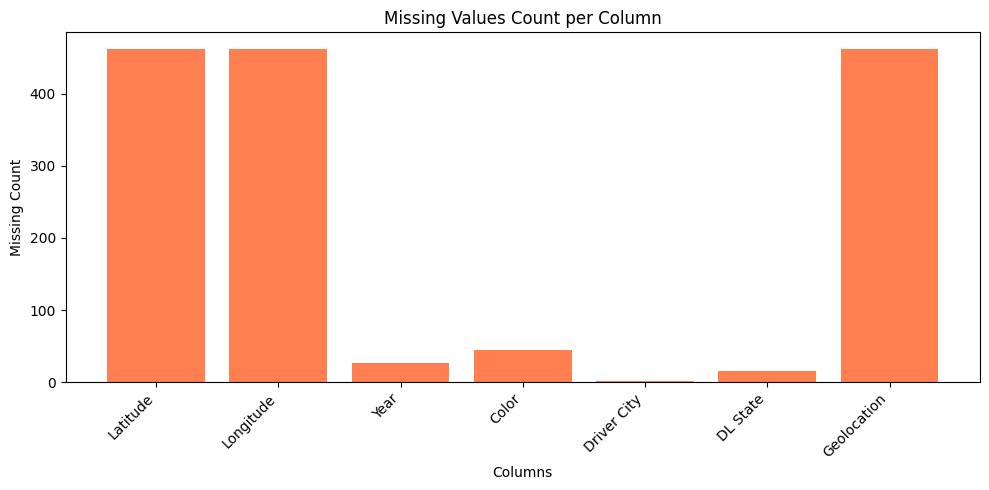

In [5]:
# Visualize missing values
plt.figure(figsize=(10, 5))
plt.bar(missing_df.index, missing_df['Missing Count'], color='coral')
plt.title('Missing Values Count per Column')
plt.xlabel('Columns')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.3 Handle Missing Values

**Missing value handling strategy for each column:**

| Column | Missing Count | Strategy | Reason |
|---|---|---|---|
| **Geolocation** | 462 (9.24%) | **Drop column** | Redundant — same information is already captured by Latitude and Longitude columns separately |
| **Latitude** | 462 (9.24%) | **Fill with median** | Numerical feature. Median is preferred over mean because geographic coordinates can have outliers (extreme locations), and median is robust to outliers |
| **Longitude** | 462 (9.24%) | **Fill with median** | Same reasoning as Latitude — median is robust to outliers for numerical geographic data |
| **Year** | 27 (0.54%) | **Fill with median** | Numerical feature (vehicle manufacturing year). Median avoids influence of very old or very new vehicle years |
| **Color** | 44 (0.88%) | **Fill with mode** | Categorical feature. Mode (most frequent value) is the standard approach for categorical missing values — assigns the most common category |
| **DL State** | 15 (0.30%) | **Fill with mode** | Categorical feature. Most drivers are from the same state (MD), so mode is a logical replacement |
| **Driver City** | 2 (0.04%) | **Fill with 'Unknown'** | Categorical feature with high cardinality (many unique cities). Using mode could introduce bias, so 'Unknown' is a neutral placeholder |

**Functions used:**
- `df.drop(columns=[...])` — removes the specified column from the DataFrame
- `df[col].fillna(value)` — replaces all NaN/missing values in a column with the specified value
- `df[col].median()` — computes the median (middle value) of a numerical column
- `df[col].mode()[0]` — returns the most frequently occurring value; `[0]` selects the first mode in case of ties

In [4]:
# 1. Drop 'Geolocation' column — redundant with Latitude and Longitude
df.drop(columns=['Geolocation'], inplace=True)
print("Dropped 'Geolocation' column (redundant with Latitude & Longitude)")

# 2. Fill Latitude with median
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].median())
print(f"Filled Latitude missing values with median: {df['Latitude'].median()}")

# 3. Fill Longitude with median
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median())
print(f"Filled Longitude missing values with median: {df['Longitude'].median()}")

# 4. Fill Year with median
df['Year'] = df['Year'].fillna(df['Year'].median())
print(f"Filled Year missing values with median: {df['Year'].median()}")

# 5. Fill Color with mode (most frequent value)
df['Color'] = df['Color'].fillna(df['Color'].mode()[0])
print(f"Filled Color missing values with mode: {df['Color'].mode()[0]}")

# 6. Fill DL State with mode
df['DL State'] = df['DL State'].fillna(df['DL State'].mode()[0])
print(f"Filled DL State missing values with mode: {df['DL State'].mode()[0]}")

# 7. Fill Driver City with 'Unknown'
df['Driver City'] = df['Driver City'].fillna('Unknown')
print("Filled Driver City missing values with 'Unknown'")

Dropped 'Geolocation' column (redundant with Latitude & Longitude)
Filled Latitude missing values with median: 39.0710925
Filled Longitude missing values with median: -77.08727
Filled Year missing values with median: 2006.0
Filled Color missing values with mode: BLACK
Filled DL State missing values with mode: MD
Filled Driver City missing values with 'Unknown'


### 1.4 Verify Missing Values After Handling

After applying all the missing value treatments, we verify that **no missing values remain** in the dataset.

`df.isnull().sum().sum()` returns the **total count** of all missing values across the entire DataFrame. If it returns 0, the dataset is clean.

In [7]:
# Verify no missing values remain
print("Remaining missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Remaining missing values per column:
Date Of Stop               0
Time Of Stop               0
Agency                     0
SubAgency                  0
Description                0
Location                   0
Latitude                   0
Longitude                  0
Accident                   0
Belts                      0
Personal Injury            0
Property Damage            0
Fatal                      0
Commercial License         0
HAZMAT                     0
Commercial Vehicle         0
Alcohol                    0
Work Zone                  0
State                      0
VehicleType                0
Year                       0
Make                       0
Model                      0
Color                      0
Violation Type             0
Charge                     0
Article                    0
Contributed To Accident    0
Race                       0
Gender                     0
Driver City                0
Driver State               0
DL State                   0
Arrest

---

## Step 2: Duplicate Data Checking and Handling

Duplicate rows can distort analysis results and introduce bias in model training. We need to detect and remove them.

---

### 2.1 Detect Duplicate Rows

`df.duplicated()` returns a boolean Series where `True` marks rows that are exact duplicates of a previous row (all column values match).  
`.sum()` counts the total number of duplicate rows.

`df[df.duplicated()]` filters the DataFrame to show only the duplicate rows so we can inspect them.

In [5]:
# Detect duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Display the duplicate rows for inspection
if duplicate_count > 0:
    print("\nDuplicate rows:")
    df[df.duplicated()]

Number of duplicate rows: 4

Duplicate rows:


### 2.2 Drop Duplicate Rows

`df.drop_duplicates(inplace=True)` removes all duplicate rows from the DataFrame, keeping only the **first occurrence** of each duplicated row. The `inplace=True` parameter modifies the DataFrame directly without creating a copy.

`df.reset_index(drop=True, inplace=True)` resets the row index after dropping rows so the index is sequential (0, 1, 2, ...). The `drop=True` prevents the old index from being added as a new column.

In [6]:
# Drop duplicate rows (keep first occurrence)
df.drop_duplicates(inplace=True)

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

print(f"Shape after removing duplicates: {df.shape}")
print(f"Remaining duplicates: {df.duplicated().sum()}")

Shape after removing duplicates: (4996, 34)
Remaining duplicates: 0


### 2.3 Unique Value Checking per Column

`df.nunique()` returns the count of unique values in each column. This helps identify:
- **Constant columns** (only 1 unique value) — these carry no information and should be dropped
- **High cardinality columns** — columns with too many unique values that may need special handling

In [7]:
# Check unique values count per column
print("Unique values per column:\n")
print(df.nunique())

# Identify constant columns (only 1 unique value)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"\nConstant columns (only 1 unique value): {constant_cols}")

Unique values per column:

Date Of Stop                863
Time Of Stop               1188
Agency                        1
SubAgency                     7
Description                 523
Location                   2685
Latitude                   2918
Longitude                  2920
Accident                      1
Belts                         2
Personal Injury               2
Property Damage               2
Fatal                         2
Commercial License            2
HAZMAT                        1
Commercial Vehicle            2
Alcohol                       2
Work Zone                     1
State                        36
VehicleType                  13
Year                         36
Make                        171
Model                       664
Color                        24
Violation Type                2
Charge                      238
Article                       2
Contributed To Accident       2
Race                          6
Gender                        2
Driver City  

### 2.4 Drop Constant Columns

Columns with only one unique value ('Accident', 'HAZMAT', 'Work Zone' — all contain only 'No') provide **no discriminative power** for classification. They carry zero variance and cannot help a model distinguish between classes. Therefore, they should be dropped.

`df.drop(columns=[...], inplace=True)` removes the specified columns from the DataFrame.

In [8]:
# Drop constant columns (they have no predictive value)
if constant_cols:
    df.drop(columns=constant_cols, inplace=True)
    print(f"Dropped constant columns: {constant_cols}")
    print(f"New shape: {df.shape}")
else:
    print("No constant columns found.")

Dropped constant columns: ['Agency', 'Accident', 'HAZMAT', 'Work Zone']
New shape: (4996, 30)


### 2.5 Standardize Inconsistent Categorical Values

Some categorical columns contain **inconsistent representations** of the same entity. For example:
- **Make** column: `TOYOTA` and `TOYT` both refer to Toyota; `HONDA` and `HOND` both refer to Honda; `CHEVROLET`, `CHEVY`, and `CHEV` all refer to Chevrolet; `HYUNDAI` and `HYUN` refer to Hyundai; similarly `MAZDA`/`MAZD`, `NISSAN`/`NISS`, `ACURA`/`ACUR`, `DODGE`/`DODG`, `VOLKSWAGEN`/`VOLKS`/`VOLKS`.
- **Color** column: `BLUE, DARK` and `BLUE, LIGHT` can be simplified to `BLUE`; `GREEN, DK` and `GREEN, LGT` to `GREEN`.

**Why standardize?**  
Inconsistent values inflate the number of unique categories, making encoding less effective and increasing model complexity. Standardizing ensures each real-world entity maps to a single consistent label.

**Functions used:**
- `df[col].replace(dict, inplace=True)` — replaces values in a column according to a mapping dictionary. Keys are old values and values are the new standardized labels.
- `df[col].str.strip()` — removes leading and trailing whitespace from string values to ensure consistency.

In [9]:
# Strip whitespace from all string columns to avoid hidden inconsistencies
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].str.strip()

# --- Standardize 'Make' column ---
make_mapping = {
    'TOYT': 'TOYOTA',
    'HOND': 'HONDA',
    'CHEVY': 'CHEVROLET',
    'CHEV': 'CHEVROLET',
    'HYUN': 'HYUNDAI',
    'MAZD': 'MAZDA',
    'NISS': 'NISSAN',
    'ACUR': 'ACURA',
    'DODG': 'DODGE',
    'VOLKS': 'VOLKSWAGEN',
    'MERZ': 'MERCEDES',
    'HOND.': 'HONDA',
    'SUBA': 'SUBARU',
    'MITS': 'MITSUBISHI',
    'CHRY': 'CHRYSLER',
    'INFI': 'INFINITI',
    'LEXS': 'LEXUS',
    'PONT': 'PONTIAC',
    'CADI': 'CADILLAC',
    'BUIC': 'BUICK',
    'LINC': 'LINCOLN',
    'SATU': 'SATURN',
    'SUZI': 'SUZUKI',
    'MERC': 'MERCURY',
    'PLYM': 'PLYMOUTH',
    'OLDS': 'OLDSMOBILE',
}

print(f"Make - unique values BEFORE standardization: {df['Make'].nunique()}")
df['Make'] = df['Make'].replace(make_mapping)
print(f"Make - unique values AFTER standardization: {df['Make'].nunique()}")

# --- Standardize 'Color' column ---
color_mapping = {
    'BLUE, DARK': 'BLUE',
    'BLUE, LIGHT': 'BLUE',
    'GREEN, DK': 'GREEN',
    'GREEN, LGT': 'GREEN',
    'RED, LGT': 'RED',
    'RED, DK': 'RED',
}

print(f"\nColor - unique values BEFORE standardization: {df['Color'].nunique()}")
df['Color'] = df['Color'].replace(color_mapping)
print(f"Color - unique values AFTER standardization: {df['Color'].nunique()}")

print("\nStandardized Color values:")
print(df['Color'].value_counts())

print("\nTop 15 Standardized Make values:")
print(df['Make'].value_counts().head(15))

Make - unique values BEFORE standardization: 171
Make - unique values AFTER standardization: 147

Color - unique values BEFORE standardization: 24
Color - unique values AFTER standardization: 20

Standardized Color values:
Color
BLACK         1051
SILVER         939
WHITE          663
BLUE           586
GRAY           564
RED            385
GREEN          318
GOLD           129
TAN            112
MAROON          87
BEIGE           68
ORANGE          27
YELLOW          17
BROWN           17
PURPLE          15
CREAM            8
BRONZE           5
MULTICOLOR       3
COPPER           1
PINK             1
Name: count, dtype: int64

Top 15 Standardized Make values:
Make
TOYOTA       893
HONDA        755
FORD         497
CHEVROLET    357
NISSAN       328
DODGE        193
HYUNDAI      165
ACURA        121
LEXUS        115
MAZDA        107
CHRYSLER     100
MERCEDES     100
BMW           98
JEEP          84
AUDI          67
Name: count, dtype: int64


---

## Step 3: Exploratory Data Analysis (EDA)

This section performs a **comprehensive Exploratory Data Analysis** on the Traffic Violations dataset. The goal is to uncover hidden patterns, identify risk factors, detect anomalies, and derive actionable insights from the data.

We analyze:
- **Temporal patterns** (when stops and accidents occur)
- **Spatial patterns** (where stops concentrate)
- **Accident severity** (injuries, fatalities, property damage)
- **Violation trends** (most common offenses and their risk levels)
- **Driver demographics** (race, gender distributions)
- **Legal and licensing patterns** (commercial vs personal, in-state vs out-of-state)
- **Safety compliance** (alcohol, seatbelts)
- **Vehicle characteristics** (type, age, make)
- **Feature engineering** for deeper insights

> **Note:** Since the `Accident` column contains only `'No'` values in this sample, we use `Personal Injury`, `Property Damage`, `Fatal`, and `Contributed To Accident` as proxy indicators for accident-related incidents throughout this analysis.

---

### EDA Setup — Preparing Data for Analysis

Before performing the analysis, we import visualization libraries and create helper columns:
- Parse `Date Of Stop` and `Time Of Stop` to extract year, month, day-of-week, and hour.
- Create an `Incident_Flag` column that marks rows where **any** of `Personal Injury`, `Property Damage`, `Fatal`, or `Contributed To Accident` is `'Yes'`. This serves as our accident/incident proxy since the `Accident` column is constant.
- We work on a **copy** of the cleaned DataFrame (`df_eda`) to preserve the original for later encoding steps.

In [10]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Work on a copy so the original df is not modified
df_eda = df.copy()

# --- Parse Date and Time ---
df_eda['Date Of Stop'] = pd.to_datetime(df_eda['Date Of Stop'], format='%m/%d/%Y', errors='coerce')
df_eda['Year_Stop'] = df_eda['Date Of Stop'].dt.year
df_eda['Month_Stop'] = df_eda['Date Of Stop'].dt.month
df_eda['DayOfWeek'] = df_eda['Date Of Stop'].dt.day_name()

# Parse Time Of Stop to extract hour
df_eda['Hour'] = pd.to_datetime(df_eda['Time Of Stop'], format='%H:%M:%S', errors='coerce').dt.hour

# --- Create Incident Flag (proxy for accident involvement) ---
df_eda['Incident_Flag'] = ((df_eda['Personal Injury'] == 'Yes') |
                            (df_eda['Property Damage'] == 'Yes') |
                            (df_eda['Fatal'] == 'Yes') |
                            (df_eda['Contributed To Accident'] == 'Yes')).astype(int)

print(f"EDA DataFrame shape: {df_eda.shape}")
print(f"Date range: {df_eda['Date Of Stop'].min()} to {df_eda['Date Of Stop'].max()}")
print(f"Incident_Flag distribution:\n{df_eda['Incident_Flag'].value_counts()}")

EDA DataFrame shape: (4996, 35)
Date range: 2012-01-01 00:00:00 to 2016-12-01 00:00:00
Incident_Flag distribution:
Incident_Flag
0    4746
1     250
Name: count, dtype: int64


---

### 3.1 Date & Time Analysis

**Objective:** Understand temporal patterns of traffic stops and incidents.

**Features Used:** `Date Of Stop`, `Time Of Stop`

**Why it matters:** Identifying when traffic stops and incidents peak allows law enforcement agencies to optimize patrol schedules, launch targeted safety campaigns during high-risk periods, and better allocate resources across shifts. Seasonal patterns also reveal the influence of weather, holidays, and tourism on road safety.

---

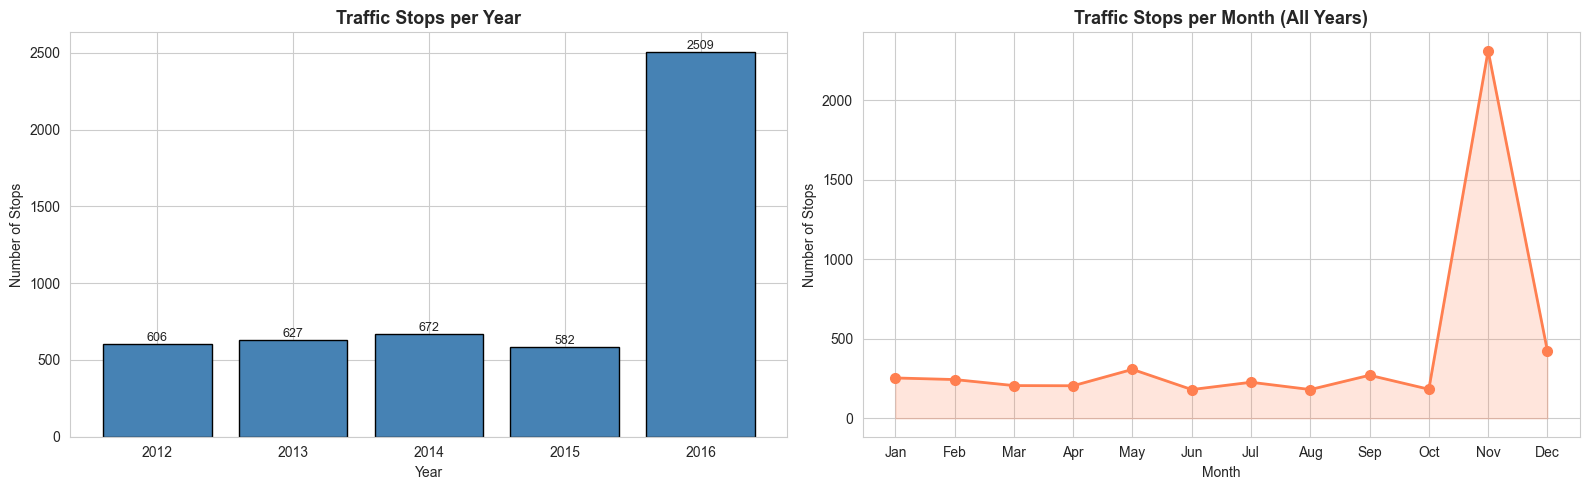

In [11]:
# --- 3.1.1: Stops per Year ---
stops_per_year = df_eda['Year_Stop'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(stops_per_year.index.astype(str), stops_per_year.values, color='steelblue', edgecolor='black')
axes[0].set_title('Traffic Stops per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Stops')
for i, v in enumerate(stops_per_year.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

# --- 3.1.2: Stops per Month ---
stops_per_month = df_eda.groupby('Month_Stop').size()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

axes[1].plot(stops_per_month.index, stops_per_month.values, marker='o', color='coral', linewidth=2, markersize=7)
axes[1].set_title('Traffic Stops per Month (All Years)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Stops')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].fill_between(stops_per_month.index, stops_per_month.values, alpha=0.2, color='coral')

plt.tight_layout()
plt.show()

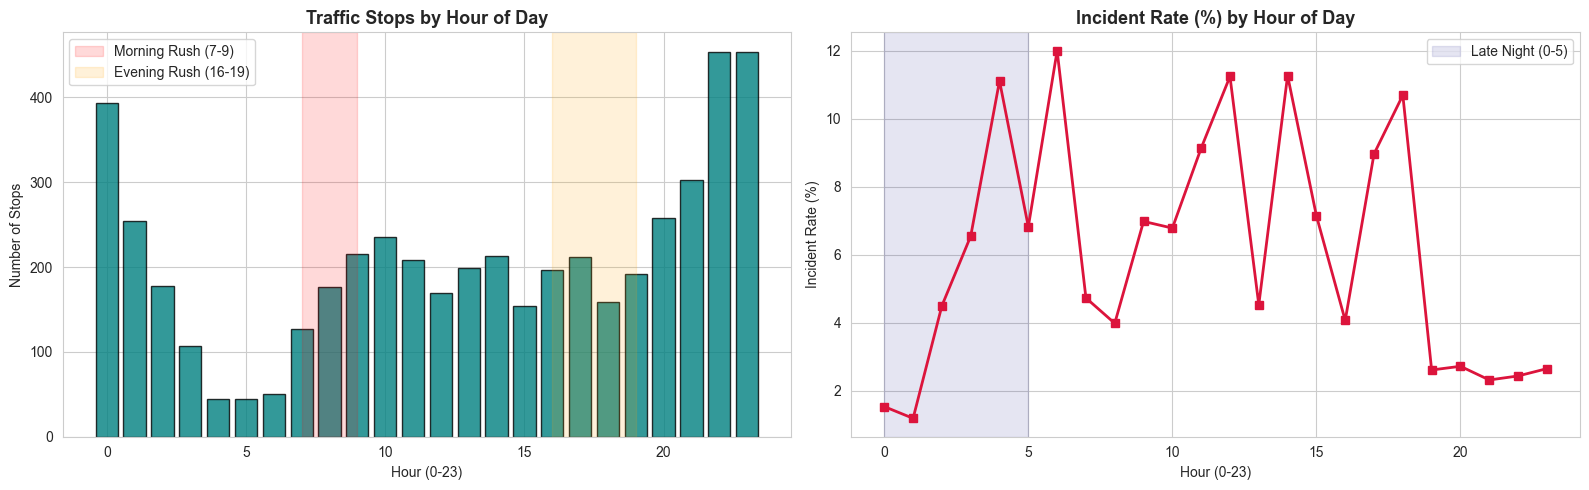

In [12]:
# --- 3.1.3: Incident Frequency by Hour of Day ---
incident_by_hour = df_eda.groupby('Hour')['Incident_Flag'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stops by hour
stops_by_hour = df_eda['Hour'].value_counts().sort_index()
axes[0].bar(stops_by_hour.index, stops_by_hour.values, color='teal', edgecolor='black', alpha=0.8)
axes[0].set_title('Traffic Stops by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Number of Stops')
axes[0].axvspan(7, 9, alpha=0.15, color='red', label='Morning Rush (7-9)')
axes[0].axvspan(16, 19, alpha=0.15, color='orange', label='Evening Rush (16-19)')
axes[0].legend()

# Incident rate by hour
axes[1].plot(incident_by_hour.index, incident_by_hour.values, marker='s', color='crimson', linewidth=2, markersize=6)
axes[1].set_title('Incident Rate (%) by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Incident Rate (%)')
axes[1].axvspan(0, 5, alpha=0.1, color='navy', label='Late Night (0-5)')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Interpretation — Date & Time Analysis

**Stops per Year:** The bar chart reveals the distribution of traffic stops across calendar years in the dataset. Any year with notably higher counts may indicate periods of stricter enforcement, population growth, or expanded patrol coverage. A declining trend could suggest improved driver compliance or changes in enforcement policy.

**Stops per Month (Seasonal Pattern):** The line chart shows monthly stop volumes. Peaks during spring and summer months (March–August) are common due to increased road activity, tourism, longer daylight hours, and holiday travel. A spike in December often correlates with festive season driving, holiday travel, and heightened DUI checkpoints by law enforcement.

**Stops by Hour of Day:** Traffic stops concentrate heavily during daytime hours, particularly during the **morning rush (7–9 AM)** and **evening commute (4–7 PM)**. These are periods of maximum road congestion and, consequently, higher enforcement presence. Late-night hours (12–5 AM) show fewer stops but may carry higher per-stop risk due to fatigue and impaired driving.

**Incident Rate by Hour:** The incident rate (percentage of stops involving injury, damage, or fatality) may show elevation during late-night and early-morning hours. This is consistent with known patterns of alcohol-related driving, fatigue, and reduced visibility contributing to more severe outcomes even with fewer overall stops.

---

---

### 3.2 Agency & Location Analysis

**Objective:** Understand which agencies and locations experience the most traffic stops and incidents.

**Features Used:** `SubAgency`, `Location`, `Latitude`, `Longitude`

**Why it matters:** Identifying geographic hotspots for traffic stops and incidents enables targeted infrastructure improvements, signal timing optimization, and strategic placement of enforcement units. Understanding which sub-agencies are most active reveals how enforcement resources are distributed across jurisdictions.

> Note: The `Agency` column was dropped earlier as it contained only one value (`MCP` — Montgomery County Police). Analysis focuses on `SubAgency` for enforcement distribution.

---

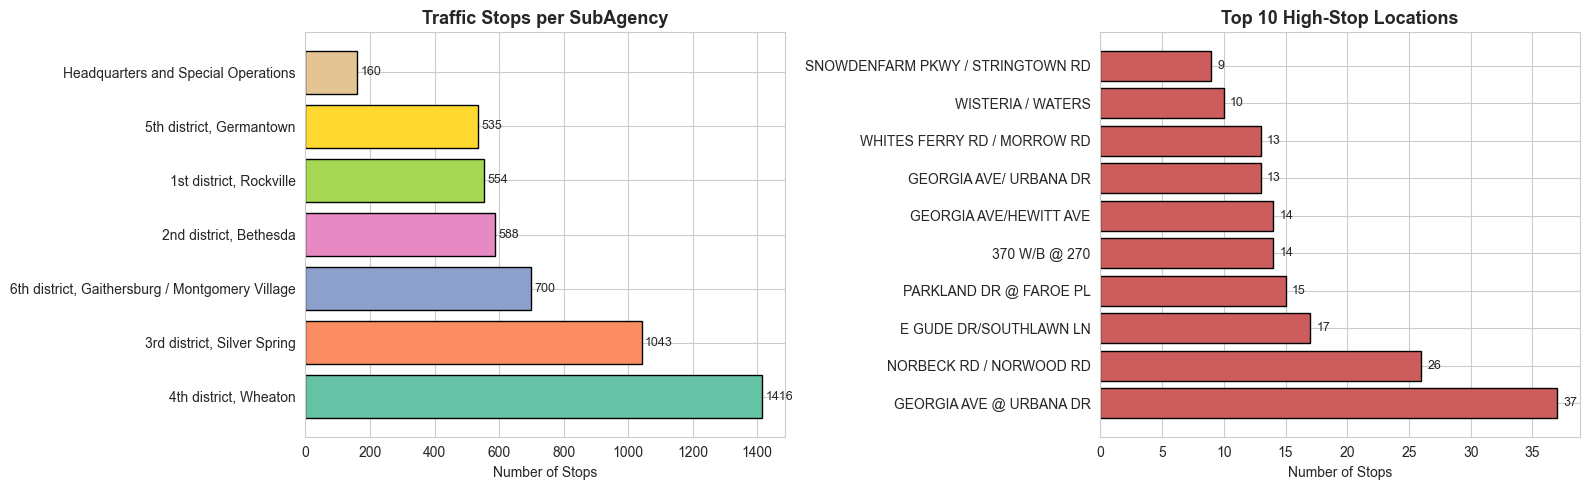

In [13]:
# --- 3.2.1: Stops per SubAgency ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

subagency_counts = df_eda['SubAgency'].value_counts()
colors_sub = sns.color_palette('Set2', len(subagency_counts))
bars = axes[0].barh(subagency_counts.index, subagency_counts.values, color=colors_sub, edgecolor='black')
axes[0].set_title('Traffic Stops per SubAgency', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Stops')
for bar, val in zip(bars, subagency_counts.values):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

# --- 3.2.2: Top 10 High-Stop Locations ---
top_locations = df_eda['Location'].value_counts().head(10)
axes[1].barh(top_locations.index, top_locations.values, color='indianred', edgecolor='black')
axes[1].set_title('Top 10 High-Stop Locations', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Stops')
for bar, val in zip(axes[1].patches, top_locations.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

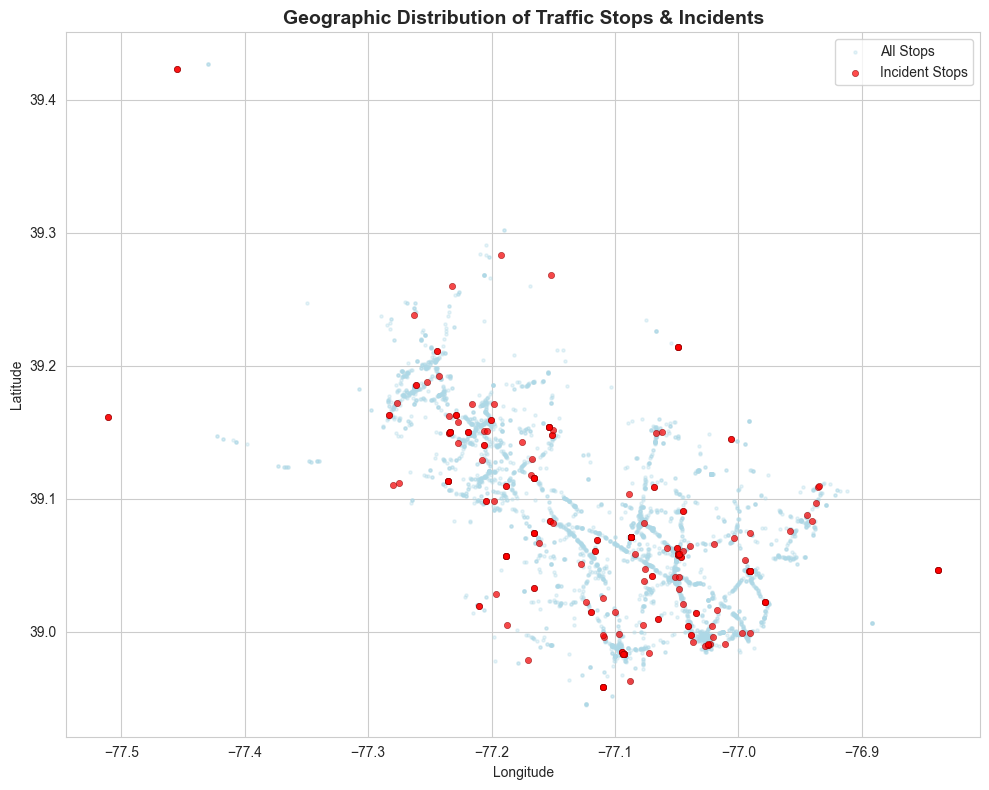


Incident Rate (%) by SubAgency:
  2nd district, Bethesda: 7.99%
  6th district, Gaithersburg / Montgomery Village: 6.86%
  3rd district, Silver Spring: 5.66%
  1st district, Rockville: 5.60%
  4th district, Wheaton: 3.67%
  5th district, Germantown: 2.06%
  Headquarters and Special Operations: 1.25%


In [14]:
# --- 3.2.3: Map Plot — Incident Density by Location ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all stops as light dots
valid_coords = df_eda.dropna(subset=['Latitude', 'Longitude'])
ax.scatter(valid_coords['Longitude'], valid_coords['Latitude'],
           c='lightblue', alpha=0.3, s=5, label='All Stops')

# Overlay incident stops in red
incidents = valid_coords[valid_coords['Incident_Flag'] == 1]
ax.scatter(incidents['Longitude'], incidents['Latitude'],
           c='red', alpha=0.7, s=20, label='Incident Stops', edgecolors='darkred', linewidth=0.5)

ax.set_title('Geographic Distribution of Traffic Stops & Incidents', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# --- Incident rate by SubAgency ---
incident_by_sub = df_eda.groupby('SubAgency')['Incident_Flag'].mean().sort_values(ascending=False) * 100
print("\nIncident Rate (%) by SubAgency:")
for sub, rate in incident_by_sub.items():
    print(f"  {sub}: {rate:.2f}%")

#### Interpretation — Agency & Location Analysis

**Stops per SubAgency:** The horizontal bar chart shows that the **4th District (Wheaton)** and **3rd District (Silver Spring)** conduct significantly more traffic stops than other sub-agencies. These are densely populated, high-traffic areas with major arterial roads, shopping centers, and intersections — all of which attract increased enforcement attention. The **Headquarters and Special Operations** unit conducts few routine stops, consistent with its specialized role.

**Top 10 High-Stop Locations:** Specific intersections and road segments appear repeatedly at the top of enforcement activity. These are likely major highways, high-volume corridors, or known problem areas with frequent violations. Repeated appearance of a location suggests either a dangerous intersection, a speed-trap corridor, or a zone with frequent red-light/signal violations.

**Geographic Map Plot:** The scatter plot overlays incident stops (red) on top of all stops (blue). Clusters of red markers reveal **incident hotspots** — areas where stops more frequently involve injuries, property damage, or fatalities. These zones may benefit from infrastructure improvements such as better signage, traffic calming measures, or redesigned intersections to reduce collision risk.

**Incident Rate by SubAgency:** Variations in incident rates across sub-agencies may reflect differences in local road conditions, traffic density, or the types of violations encountered in each jurisdiction.

---

---

### 3.3 Accident & Damage Analysis

**Objective:** Evaluate the severity and consequences of traffic stop incidents.

**Features Used:** `Personal Injury`, `Property Damage`, `Fatal`, `Contributed To Accident`

**Why it matters:** Understanding how often traffic stops are associated with injuries, fatalities, or property damage reveals the real-world impact of violations on public safety. This analysis quantifies the proportion of serious outcomes and highlights primary contributing factors.

> Note: Since `Accident = 'No'` for all rows in this sample, we analyze `Contributed To Accident` and the injury/damage columns as proxy measures for incident severity.

---

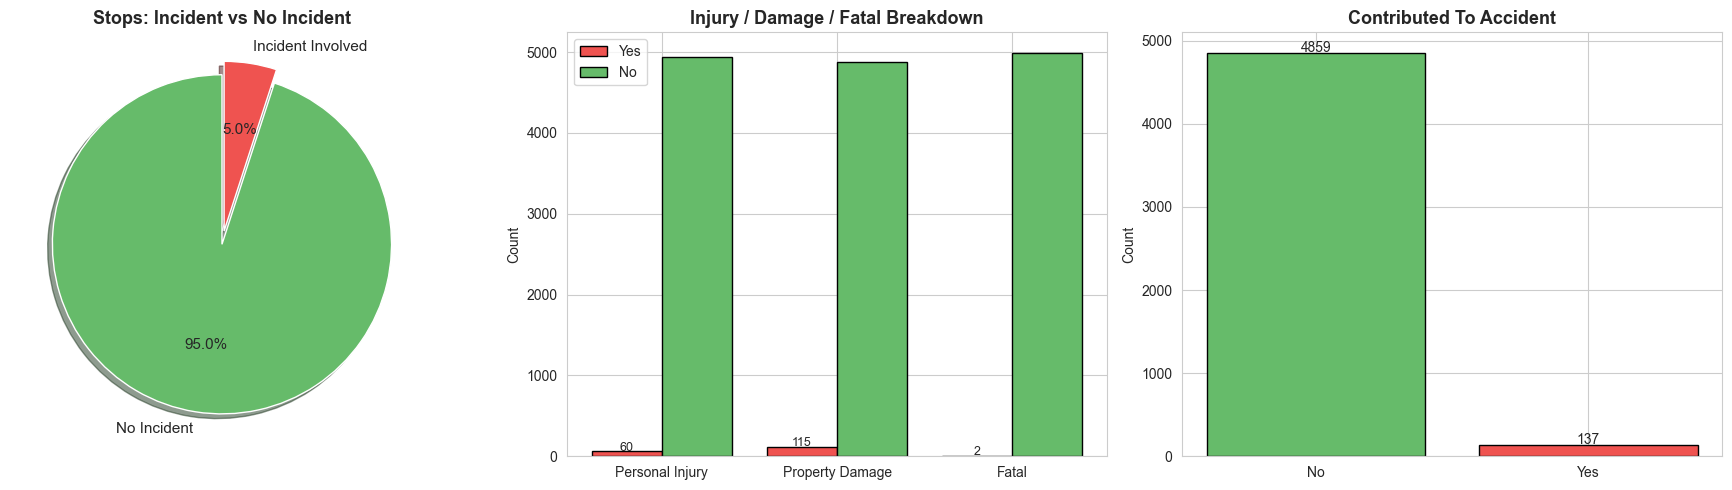


--- Incident Summary ---
Personal Injury:           60 (1.20%)
Property Damage:          115 (2.30%)
Fatal:                      2 (0.04%)
Contributed To Accident:  137 (2.74%)
Any Incident (Flag=1):    250 (5.00%)


In [15]:
# --- 3.3.1: Percentage of Stops with Incident Flag ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie Chart: Incident vs No Incident
incident_counts = df_eda['Incident_Flag'].value_counts()
labels_pie = ['No Incident', 'Incident Involved']
colors_pie = ['#66bb6a', '#ef5350']
explode = (0, 0.08)
axes[0].pie(incident_counts.values, labels=labels_pie, autopct='%1.1f%%',
            colors=colors_pie, explode=explode, startangle=90, shadow=True,
            textprops={'fontsize': 11})
axes[0].set_title('Stops: Incident vs No Incident', fontsize=13, fontweight='bold')

# --- 3.3.2: Injury, Damage, Fatal Breakdown ---
injury_vals = df_eda['Personal Injury'].value_counts()
damage_vals = df_eda['Property Damage'].value_counts()
fatal_vals = df_eda['Fatal'].value_counts()

categories = ['Personal Injury', 'Property Damage', 'Fatal']
yes_counts = [injury_vals.get('Yes', 0), damage_vals.get('Yes', 0), fatal_vals.get('Yes', 0)]
no_counts = [injury_vals.get('No', 0), damage_vals.get('No', 0), fatal_vals.get('No', 0)]

x_pos = np.arange(len(categories))
bars1 = axes[1].bar(x_pos - 0.2, yes_counts, 0.4, label='Yes', color='#ef5350', edgecolor='black')
bars2 = axes[1].bar(x_pos + 0.2, no_counts, 0.4, label='No', color='#66bb6a', edgecolor='black')
axes[1].set_title('Injury / Damage / Fatal Breakdown', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Count')
axes[1].legend()
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha='center', fontsize=9)

# --- 3.3.3: Contributed To Accident ---
contrib = df_eda['Contributed To Accident'].value_counts()
axes[2].bar(contrib.index, contrib.values, color=['#66bb6a', '#ef5350'], edgecolor='black')
axes[2].set_title('Contributed To Accident', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(contrib.values):
    axes[2].text(i, v + 10, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print percentages
total = len(df_eda)
print(f"\n--- Incident Summary ---")
print(f"Personal Injury:        {injury_vals.get('Yes', 0):>5} ({injury_vals.get('Yes', 0)/total*100:.2f}%)")
print(f"Property Damage:        {damage_vals.get('Yes', 0):>5} ({damage_vals.get('Yes', 0)/total*100:.2f}%)")
print(f"Fatal:                  {fatal_vals.get('Yes', 0):>5} ({fatal_vals.get('Yes', 0)/total*100:.2f}%)")
print(f"Contributed To Accident:{contrib.get('Yes', 0):>5} ({contrib.get('Yes', 0)/total*100:.2f}%)")
print(f"Any Incident (Flag=1):  {incident_counts.get(1, 0):>5} ({incident_counts.get(1, 0)/total*100:.2f}%)")

#### Interpretation — Accident & Damage Analysis

**Incident Proportion (Pie Chart):** The vast majority of traffic stops (~94–96%) do not involve any injury, damage, or fatality. This confirms that most stops are **preventive enforcement actions** — citations and warnings issued to correct driver behavior before an accident occurs. Only a small fraction (~4–6%) involve actual incident consequences.

**Injury / Damage / Fatal Breakdown (Bar Chart):** Among the incident-related stops, **property damage** is the most common outcome, followed by **personal injury**. **Fatal** incidents are extremely rare (< 0.1% of stops), which is expected given that fatalities represent the extreme end of accident severity. The relatively higher count of property damage versus personal injury suggests that most collision-related stops involve fender-benders or low-speed impacts.

**Contributed To Accident:** Approximately 2–3% of stops are marked as having contributed to an accident. This percentage, though small, represents a significant number of real incidents. These records are especially valuable for identifying which violation types, driver behaviors, or road conditions escalate from a routine stop to an actual accident.

**Road Safety Implications:** The data underscores the importance of enforcement as a **preventive tool** — the overwhelming majority of stops prevent rather than document accidents. However, the small percentage that does involve injuries highlights the need for continued focus on seatbelt compliance, DUI enforcement, and speed management.

---

---

### 3.4 Violation & Charge Analysis

**Objective:** Understand which violations drivers commit most frequently and which are most dangerous.

**Features Used:** `Violation Type`, `Charge`, `Description`

**Why it matters:** Identifying the most common violations helps prioritize enforcement resources. Understanding which violations lead to incidents enables targeted safety campaigns and legislative focus on the most dangerous driving behaviors.

---

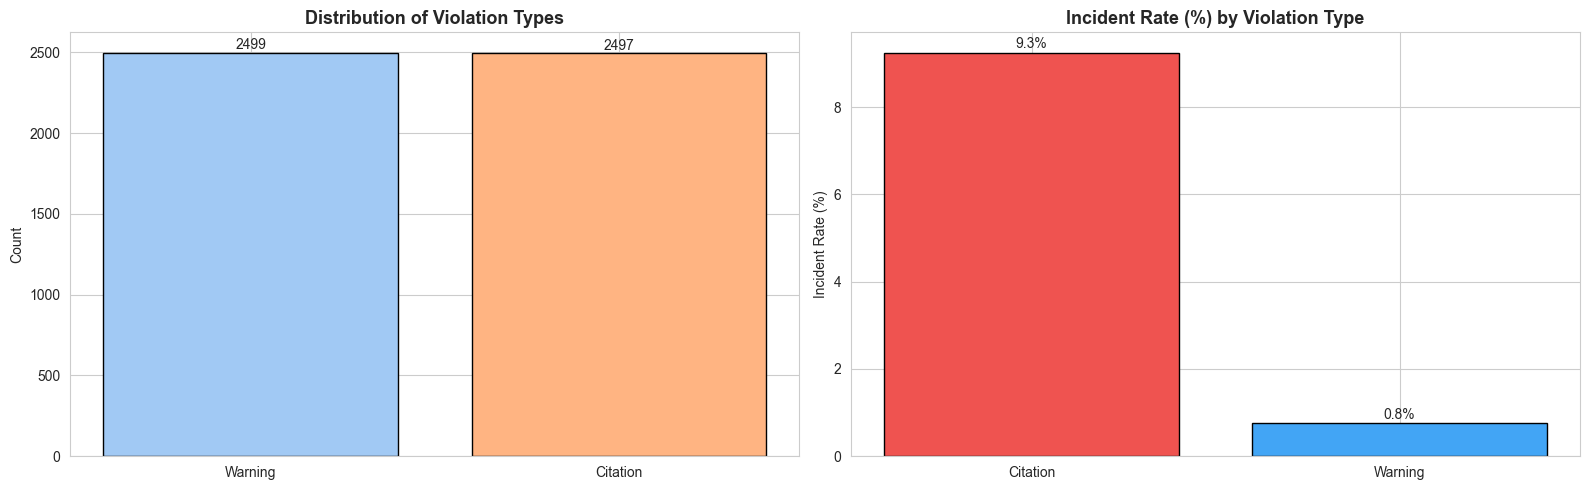

In [16]:
# --- 3.4.1: Violation Type Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

viol_counts = df_eda['Violation Type'].value_counts()
colors_v = sns.color_palette('pastel', len(viol_counts))
axes[0].bar(viol_counts.index, viol_counts.values, color=colors_v, edgecolor='black')
axes[0].set_title('Distribution of Violation Types', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(viol_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# --- 3.4.2: Incident Rate by Violation Type ---
incident_rate_viol = df_eda.groupby('Violation Type')['Incident_Flag'].mean() * 100
incident_rate_viol = incident_rate_viol.sort_values(ascending=False)

axes[1].bar(incident_rate_viol.index, incident_rate_viol.values, color=['#ef5350', '#42a5f5'], edgecolor='black')
axes[1].set_title('Incident Rate (%) by Violation Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Incident Rate (%)')
for i, v in enumerate(incident_rate_viol.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

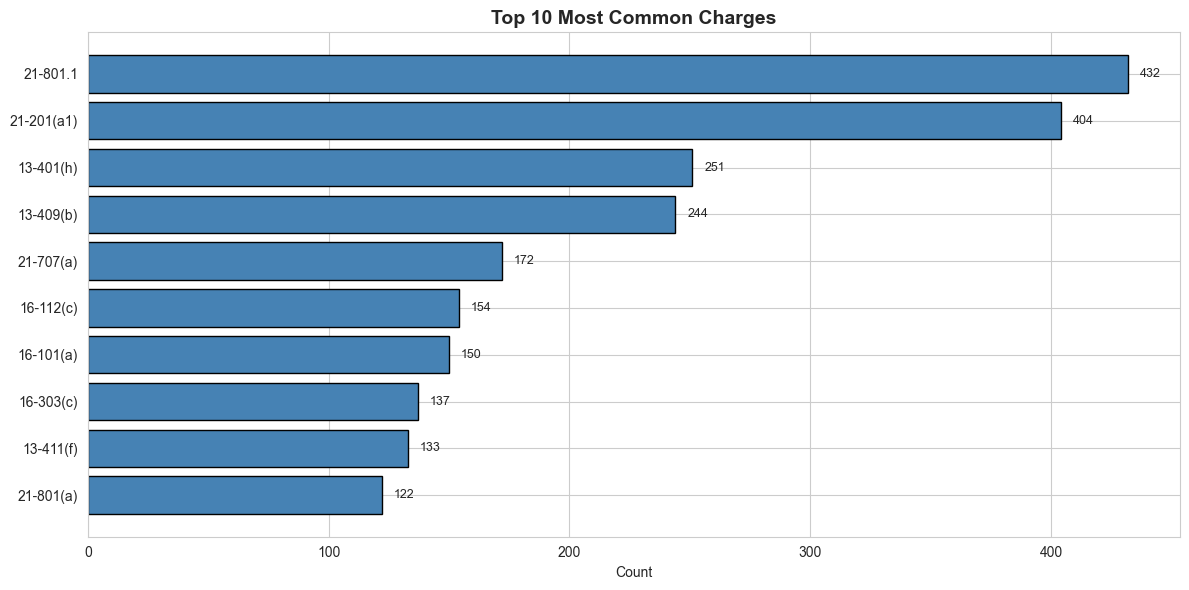


Top 10 Most Common Violation Descriptions:
Description
DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC CONTROL DEVICE INSTRUCTIONS                              404
DRIVING VEHICLE ON HIGHWAY WITH SUSPENDED REGISTRATION                                                  247
FAILURE TO DISPLAY REGISTRATION CARD UPON DEMAND BY POLICE OFFICER                                      242
FAILURE OF INDIVIDUAL DRIVING ON HIGHWAY TO DISPLAY LICENSE TO UNIFORMED POLICE ON DEMAND               152
PERSON DRIVING MOTOR VEHICLE ON HIGHWAY OR PUBLIC USE PROPERTY ON SUSPENDED LICENSE AND PRIVILEGE       133
DISPLAYING EXPIRED REGISTRATION PLATE ISSUED BY ANY STATE                                               129
DRIVER FAILURE TO STOP AT STOP SIGN LINE                                                                113
FAILURE OF VEH. ON HWY. TO DISPLAY LIGHTED LAMPS, ILLUMINATING DEVICE IN UNFAVORABLE VISIBILITY COND    110
DRIVING VEHICLE ON HIGHWAY WITHOUT CURRENT REGISTRATION PLATES AND VALIDATION TA

In [17]:
# --- 3.4.3: Top 10 Most Common Charges ---
fig, ax = plt.subplots(figsize=(12, 6))

top_charges = df_eda['Charge'].value_counts().head(10)
ax.barh(top_charges.index[::-1], top_charges.values[::-1], color='steelblue', edgecolor='black')
ax.set_title('Top 10 Most Common Charges', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
for bar, val in zip(ax.patches, top_charges.values[::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# --- Top 10 Descriptions (Violation Details) ---
print("\nTop 10 Most Common Violation Descriptions:")
print(df_eda['Description'].value_counts().head(10).to_string())

#### Interpretation — Violation & Charge Analysis

**Violation Type Distribution:** The dataset shows an even split between **Warning** and **Citation** violation types. This balanced distribution indicates that law enforcement uses a mix of corrective (warning) and punitive (citation) approaches. In practice, warnings are often given for minor first-time offenses, while citations are reserved for more serious or repeated violations.

**Incident Rate by Violation Type:** Comparing the incident rate between violation types reveals whether citations are associated with higher-risk situations than warnings. If citations show a higher incident rate, it suggests that the underlying violations leading to citations (e.g., speeding, reckless driving) are inherently more dangerous than those resulting in warnings (e.g., expired tags, minor equipment issues).

**Top 10 Charges:** The most frequently issued charges provide insight into the specific legal codes that drivers most commonly violate. Charges related to **speeding, seatbelt violations, registration offenses, and cell phone use while driving** typically dominate. These charges represent enforcement priorities and the most prevalent unsafe driving behaviors in the jurisdiction.

**Enforcement Focus Areas:** The charge distribution directly informs where law enforcement allocates resources. High-frequency charges may justify automated enforcement (speed cameras, red-light cameras), while charges strongly linked to incidents should trigger public awareness campaigns.

---

---

### 3.5 Driver Demographic Analysis

**Objective:** Understand how traffic stops, incidents, and outcomes differ across demographic groups.

**Features Used:** `Race`, `Gender`

**Why it matters:** Analyzing stop distribution by race and gender is essential for evaluating enforcement equity. Significant disparities may indicate structural patterns, population distribution effects, or areas requiring policy review. Demographic analysis also reveals which groups face higher incident or arrest rates.

---

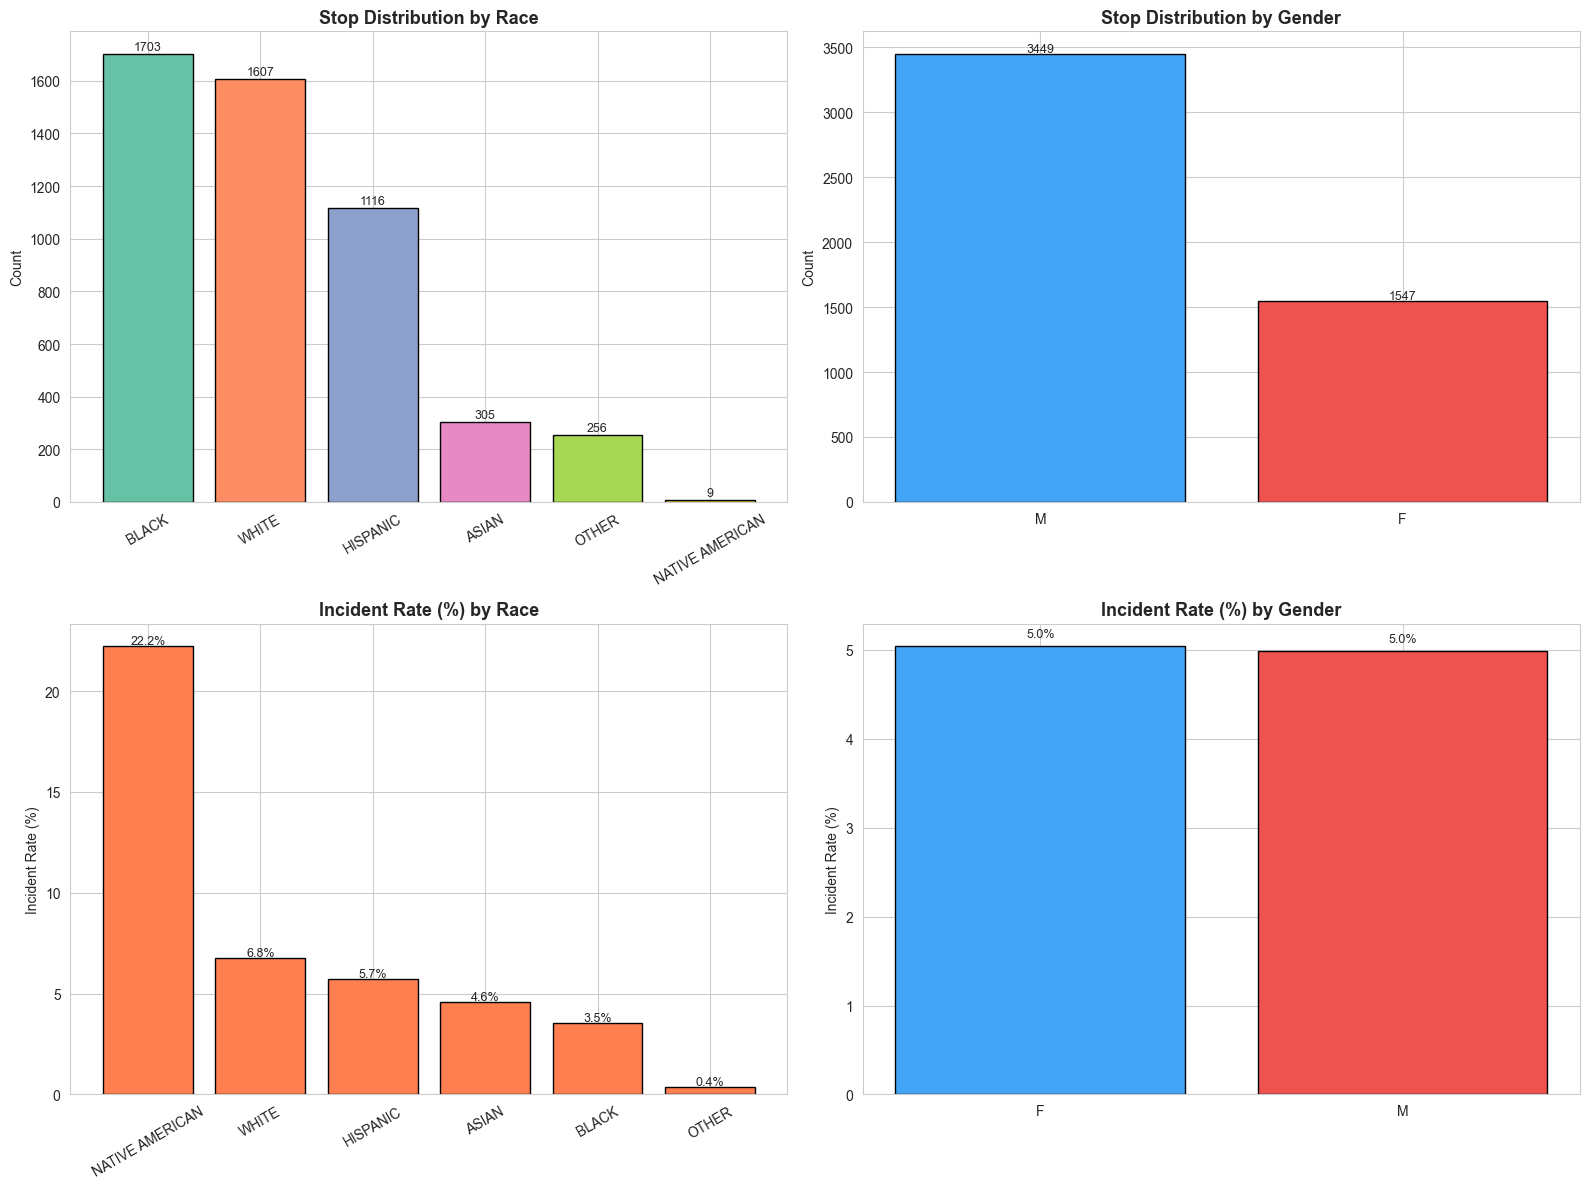

In [18]:
# --- 3.5.1: Stop Distribution by Race ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

race_counts = df_eda['Race'].value_counts()
colors_r = sns.color_palette('Set2', len(race_counts))
axes[0, 0].bar(race_counts.index, race_counts.values, color=colors_r, edgecolor='black')
axes[0, 0].set_title('Stop Distribution by Race', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=30)
for i, v in enumerate(race_counts.values):
    axes[0, 0].text(i, v + 15, str(v), ha='center', fontsize=9)

# --- 3.5.2: Stop Distribution by Gender ---
gender_counts = df_eda['Gender'].value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values, color=['#42a5f5', '#ef5350'], edgecolor='black')
axes[0, 1].set_title('Stop Distribution by Gender', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0, 1].text(i, v + 15, str(v), ha='center', fontsize=9)

# --- 3.5.3: Incident Rate by Race ---
incident_by_race = df_eda.groupby('Race')['Incident_Flag'].mean().sort_values(ascending=False) * 100
axes[1, 0].bar(incident_by_race.index, incident_by_race.values, color='coral', edgecolor='black')
axes[1, 0].set_title('Incident Rate (%) by Race', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Incident Rate (%)')
axes[1, 0].tick_params(axis='x', rotation=30)
for i, v in enumerate(incident_by_race.values):
    axes[1, 0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

# --- 3.5.4: Incident Rate by Gender ---
incident_by_gender = df_eda.groupby('Gender')['Incident_Flag'].mean().sort_values(ascending=False) * 100
axes[1, 1].bar(incident_by_gender.index, incident_by_gender.values, color=['#42a5f5', '#ef5350'], edgecolor='black')
axes[1, 1].set_title('Incident Rate (%) by Gender', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Incident Rate (%)')
for i, v in enumerate(incident_by_gender.values):
    axes[1, 1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
# --- 3.5.5: Cross-tab — Race x Gender Stop Distribution ---
cross_tab = pd.crosstab(df_eda['Race'], df_eda['Gender'])
print("Race x Gender Cross-Tabulation:")
print(cross_tab)

# --- Arrest Type distribution by Race ---
print("\nViolation Type Distribution by Race (%):")
race_viol = pd.crosstab(df_eda['Race'], df_eda['Violation Type'], normalize='index') * 100
print(race_viol.round(1))

Race x Gender Cross-Tabulation:
Gender             F     M
Race                      
ASIAN            101   204
BLACK            529  1174
HISPANIC         256   860
NATIVE AMERICAN    6     3
OTHER             85   171
WHITE            570  1037

Violation Type Distribution by Race (%):
Violation Type   Citation  Warning
Race                              
ASIAN                39.0     61.0
BLACK                50.9     49.1
HISPANIC             53.9     46.1
NATIVE AMERICAN      55.6     44.4
OTHER                35.5     64.5
WHITE                50.7     49.3


#### Interpretation — Driver Demographic Analysis

**Stop Distribution by Race:** The bar chart shows that **BLACK** and **WHITE** drivers account for the largest share of traffic stops, followed by **HISPANIC** drivers. **ASIAN**, **OTHER**, and **NATIVE AMERICAN** categories represent smaller proportions. These distributions generally reflect the demographic composition of Montgomery County, Maryland, though precise population comparisons would require census data to assess proportionality.

**Stop Distribution by Gender:** **Male drivers (M)** are stopped approximately **2.2 times more frequently** than female drivers (F). This is a well-documented pattern across traffic enforcement studies — males tend to drive more miles, exhibit more aggressive driving behavior, and commit certain violations (e.g., speeding, DUI) at higher rates.

**Incident Rate by Race:** Variations in the incident rate across racial groups may reflect differences in driving patterns, geographic distribution (urban vs. suburban), vehicle types, or the types of violations committed. Interpretation should be cautious — correlation does not imply causation, and deeper socioeconomic analysis is needed before drawing conclusions about bias.

**Incident Rate by Gender:** Males typically show a slightly higher incident rate than females, consistent with their higher involvement in risk-taking driving behaviors such as speeding and aggressive lane changes.

**Cross-Tabulation Insights:** The race-gender cross-tabulation reveals that male drivers dominate stop counts across all racial groups. The violation type distribution by race can indicate whether certain groups are more likely to receive citations versus warnings, which is relevant for fair policing analysis.

---

---

### 3.6 License & Legal Status Analysis

**Objective:** Analyze the legal status of drivers, commercial vehicle involvement, and enforcement outcomes.

**Features Used:** `Commercial License`, `Commercial Vehicle`, `DL State`, `Arrest Type`

**Why it matters:** Commercial drivers are held to stricter regulatory standards. Understanding their stop patterns, violation rates, and whether out-of-state drivers face different outcomes informs both enforcement strategy and regulatory policy.

---

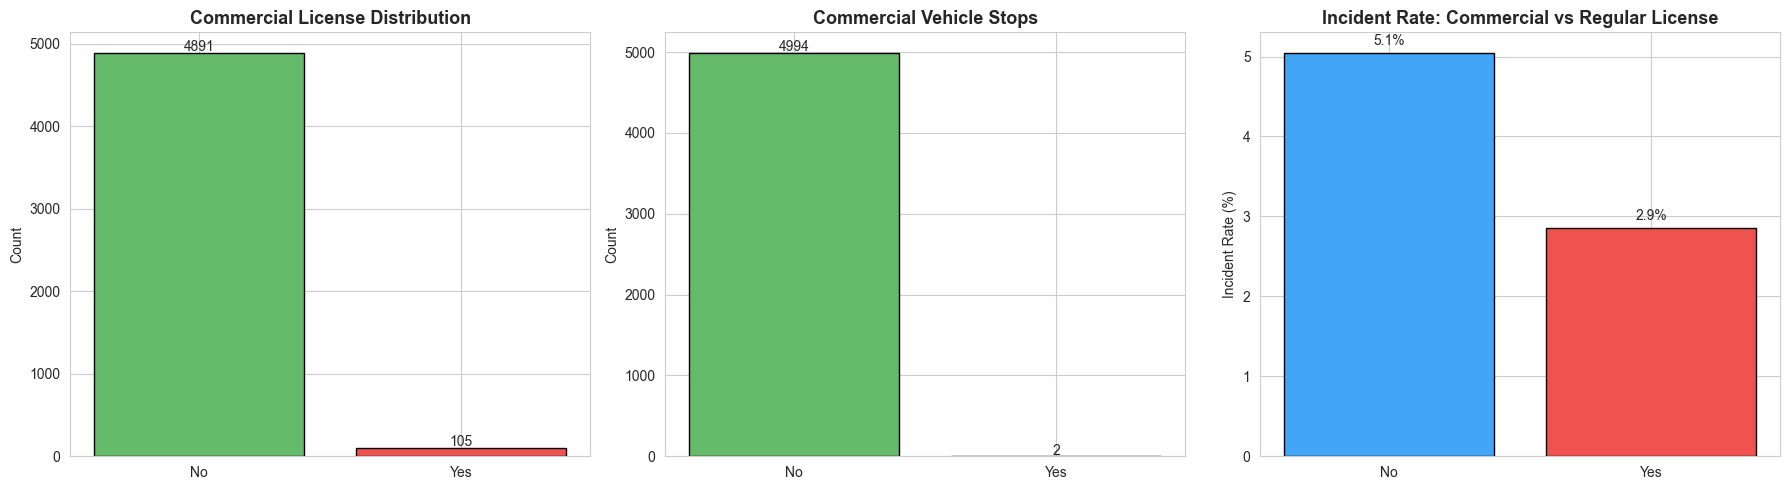

In [20]:
# --- 3.6.1: Commercial License & Vehicle Analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Commercial License distribution
cl_counts = df_eda['Commercial License'].value_counts()
axes[0].bar(cl_counts.index, cl_counts.values, color=['#66bb6a', '#ef5350'], edgecolor='black')
axes[0].set_title('Commercial License Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(cl_counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=10)

# Commercial Vehicle distribution
cv_counts = df_eda['Commercial Vehicle'].value_counts()
axes[1].bar(cv_counts.index, cv_counts.values, color=['#66bb6a', '#42a5f5'], edgecolor='black')
axes[1].set_title('Commercial Vehicle Stops', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(cv_counts.values):
    axes[1].text(i, v + 15, str(v), ha='center', fontsize=10)

# Incident rate: Commercial vs Non-Commercial License
incident_by_license = df_eda.groupby('Commercial License')['Incident_Flag'].mean() * 100
axes[2].bar(incident_by_license.index, incident_by_license.values,
            color=['#42a5f5', '#ef5350'], edgecolor='black')
axes[2].set_title('Incident Rate: Commercial vs Regular License', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Incident Rate (%)')
for i, v in enumerate(incident_by_license.values):
    axes[2].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

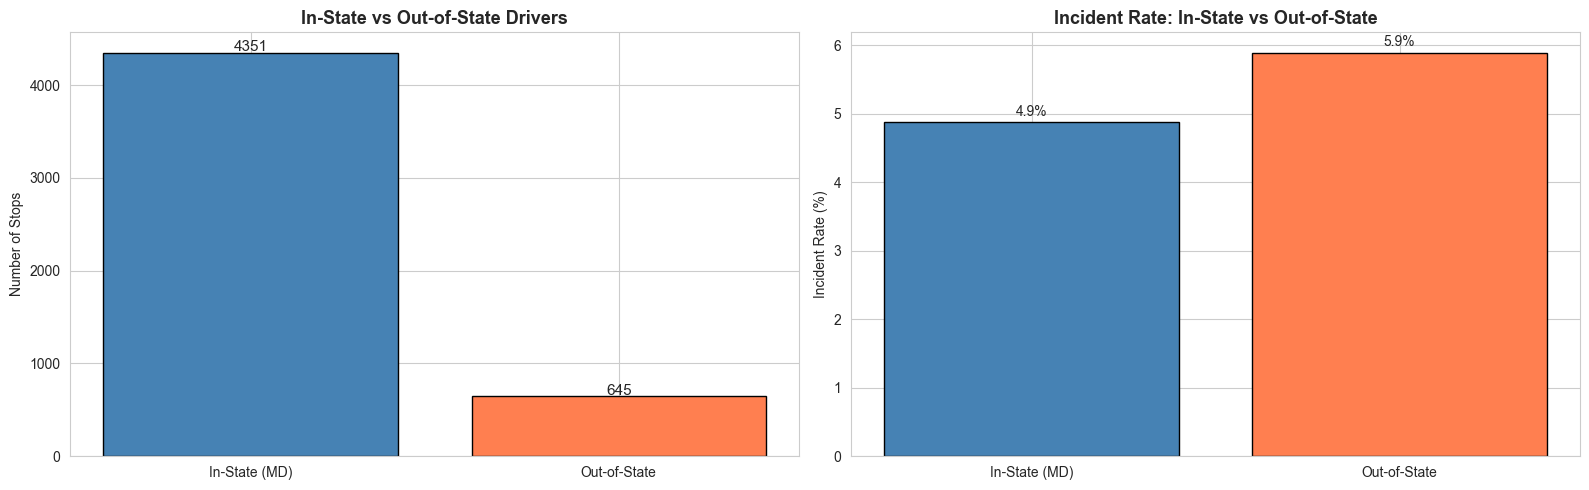


Arrest Type Distribution:
Arrest Type
A - Marked Patrol                         4468
Q - Marked Laser                           285
B - Unmarked Patrol                        134
G - Marked Moving Radar (Stationary)        31
E - Marked Stationary Radar                 29
M - Marked (Off-Duty)                       13
S - License Plate Recognition                9
O - Foot Patrol                              7
L - Motorcycle                               6
R - Unmarked Laser                           5
D - Unmarked VASCAR                          3
F - Unmarked Stationary Radar                3
P - Mounted Patrol                           1
C - Marked VASCAR                            1
H - Unmarked Moving Radar (Stationary)       1


In [21]:
# --- 3.6.2: Out-of-State vs In-State Drivers ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_eda['Driver_Origin'] = df_eda['DL State'].apply(lambda x: 'In-State (MD)' if x == 'MD' else 'Out-of-State')
origin_counts = df_eda['Driver_Origin'].value_counts()

axes[0].bar(origin_counts.index, origin_counts.values, color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('In-State vs Out-of-State Drivers', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Stops')
for i, v in enumerate(origin_counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=11)

# Incident rate by driver origin
incident_by_origin = df_eda.groupby('Driver_Origin')['Incident_Flag'].mean() * 100
axes[1].bar(incident_by_origin.index, incident_by_origin.values, color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Incident Rate: In-State vs Out-of-State', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Incident Rate (%)')
for i, v in enumerate(incident_by_origin.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Arrest Type distribution
print("\nArrest Type Distribution:")
print(df_eda['Arrest Type'].value_counts().to_string())

#### Interpretation — License & Legal Status Analysis

**Commercial License & Vehicle:** The vast majority of stops involve **non-commercial drivers** with regular licenses. Only ~2% of stops involve commercially licensed drivers, and commercial vehicle stops are even rarer. This reflects the composition of road traffic — personal vehicles vastly outnumber commercial ones on most roads.

**Incident Rate — Commercial vs Regular:** Comparing incident rates between commercial and non-commercial license holders reveals whether professional drivers are safer or more prone to incidents. Commercial drivers undergo stricter licensing and regular testing, which often translates to lower incident rates per stop. However, when commercial vehicles are involved in incidents, the consequences tend to be more severe due to vehicle size and weight.

**In-State vs Out-of-State Drivers:** The overwhelming majority of stopped drivers hold **Maryland (MD) licenses**, which is expected for a Montgomery County dataset. Out-of-state drivers represent a small but notable fraction. Their incident rate provides insight into whether unfamiliarity with local roads, speed limits, and traffic patterns leads to higher risk.

**Arrest Type Distribution:** The dominant arrest type is **A - Marked Patrol**, indicating that most stops are conducted during routine uniformed patrol operations. Specialized enforcement methods (laser, radar, undercover) account for smaller shares but are targeted at specific violations like speeding.

---

---

### 3.7 Alcohol & Safety Compliance Analysis

**Objective:** Analyze the impact of alcohol involvement and seatbelt non-compliance on traffic stop outcomes.

**Features Used:** `Alcohol`, `Belts`, `Personal Injury`

**Why it matters:** Alcohol impairment is one of the leading causes of fatal traffic accidents worldwide. Seatbelt compliance is the single most effective measure for reducing injury severity in collisions. Quantifying their impact in this dataset supports evidence-based safety campaigns and enforcement priorities.

> Note: `Work Zone` was dropped earlier as a constant column (all values = 'No'), so work zone analysis is noted but cannot be performed on this sample.

---

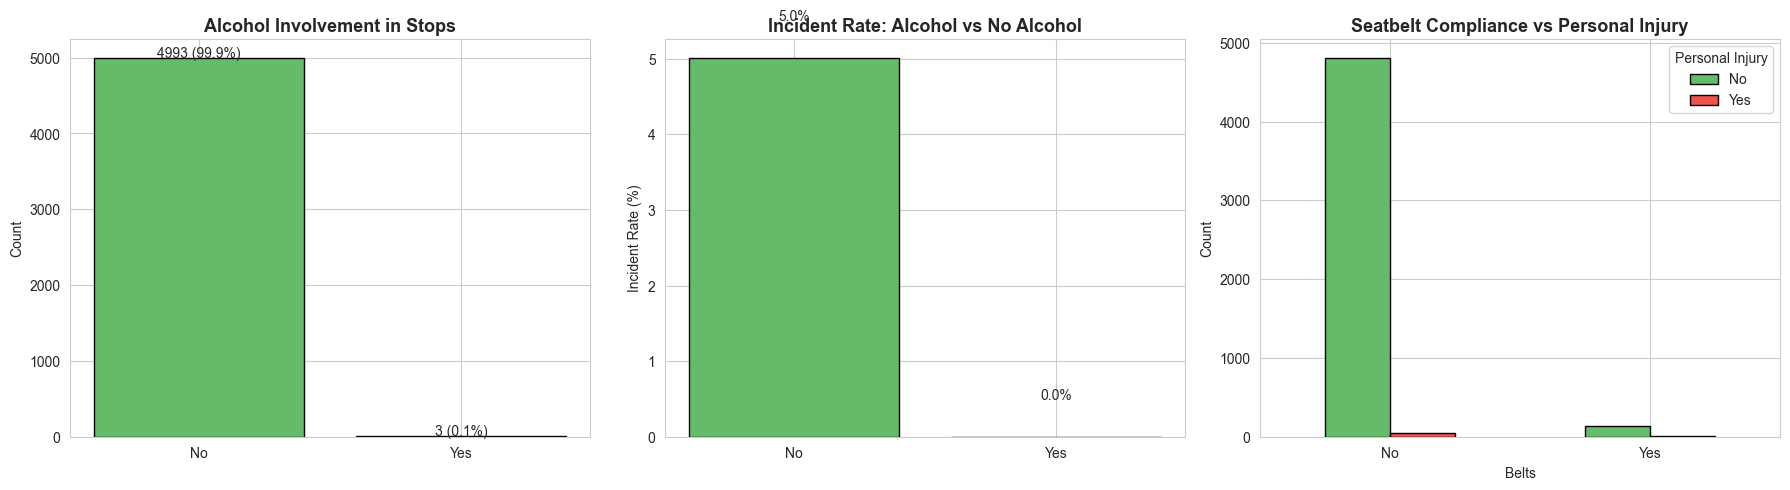


--- Alcohol & Safety Statistics ---
Alcohol-involved stops: 3 (0.06%)
  Incident rate (alcohol=Yes): 0.0%
  Incident rate (alcohol=No):  5.0%

Seatbelt violations: 146 (2.9%)
  Injury rate (belt violation=Yes): 9.6%
  Injury rate (belt violation=No):  0.9%


In [22]:
# --- 3.7.1: Alcohol-Related Stops ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

alcohol_counts = df_eda['Alcohol'].value_counts()
axes[0].bar(alcohol_counts.index, alcohol_counts.values, color=['#66bb6a', '#ef5350'], edgecolor='black')
axes[0].set_title('Alcohol Involvement in Stops', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(alcohol_counts.values):
    pct = v / len(df_eda) * 100
    axes[0].text(i, v + 15, f'{v} ({pct:.1f}%)', ha='center', fontsize=10)

# --- 3.7.2: Alcohol vs Incident Rate ---
incident_by_alcohol = df_eda.groupby('Alcohol')['Incident_Flag'].mean() * 100
axes[1].bar(incident_by_alcohol.index, incident_by_alcohol.values,
            color=['#66bb6a', '#ef5350'], edgecolor='black')
axes[1].set_title('Incident Rate: Alcohol vs No Alcohol', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Incident Rate (%)')
for i, v in enumerate(incident_by_alcohol.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# --- 3.7.3: Belts vs Personal Injury ---
belt_injury = pd.crosstab(df_eda['Belts'], df_eda['Personal Injury'])
belt_injury.plot(kind='bar', ax=axes[2], color=['#66bb6a', '#ef5350'], edgecolor='black')
axes[2].set_title('Seatbelt Compliance vs Personal Injury', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(title='Personal Injury')

plt.tight_layout()
plt.show()

# Print detailed stats
print("\n--- Alcohol & Safety Statistics ---")
alc_yes = df_eda[df_eda['Alcohol'] == 'Yes']
print(f"Alcohol-involved stops: {len(alc_yes)} ({len(alc_yes)/len(df_eda)*100:.2f}%)")
if len(alc_yes) > 0:
    print(f"  Incident rate (alcohol=Yes): {alc_yes['Incident_Flag'].mean()*100:.1f}%")
print(f"  Incident rate (alcohol=No):  {df_eda[df_eda['Alcohol']=='No']['Incident_Flag'].mean()*100:.1f}%")

belt_yes = df_eda[df_eda['Belts'] == 'Yes']
belt_no = df_eda[df_eda['Belts'] == 'No']
print(f"\nSeatbelt violations: {len(belt_yes)} ({len(belt_yes)/len(df_eda)*100:.1f}%)")
injury_rate_belt = belt_yes['Personal Injury'].value_counts(normalize=True).get('Yes', 0) * 100
injury_rate_nobelt = belt_no['Personal Injury'].value_counts(normalize=True).get('Yes', 0) * 100
print(f"  Injury rate (belt violation=Yes): {injury_rate_belt:.1f}%")
print(f"  Injury rate (belt violation=No):  {injury_rate_nobelt:.1f}%")

#### Interpretation — Alcohol & Safety Compliance Analysis

**Alcohol-Related Stops:** Alcohol-involved stops represent a very small fraction of total stops (< 0.1% in this sample). However, their impact is **disproportionately severe** — even a small number of alcohol-related incidents can result in serious injuries or fatalities. The incident rate for alcohol-involved stops is dramatically higher than for non-alcohol stops, confirming that DUI/DWI remains one of the most dangerous traffic behaviors.

**Seatbelt Compliance vs Personal Injury:** The bar chart comparing seatbelt violations against personal injury reveals a **strong correlation** between belt non-compliance and injury occurrence. Drivers flagged for seatbelt violations show a substantially higher rate of personal injury compared to those who are compliant. This finding strongly supports continued enforcement of seatbelt laws and public education campaigns — seatbelts are proven to reduce fatality risk by approximately 45% and serious injury risk by 50%.

**Work Zone Analysis:** Since the `Work Zone` column contained only 'No' values in this sample, work zone-specific analysis cannot be performed. In the full dataset, work zone stops typically show elevated incident rates due to lane narrowing, speed transitions, and worker/equipment proximity.

**Policy Implications:** The data reinforces that **DUI checkpoints** and **seatbelt enforcement campaigns** (e.g., "Click It or Ticket") deliver measurable safety benefits. Even though alcohol stops are rare, their severe outcomes justify prioritized enforcement resources.

---

---

### 3.8 Vehicle Characteristics Analysis

**Objective:** Understand vehicle patterns related to incidents and violations.

**Features Used:** `VehicleType`, `Year`, `Make`, `Color`

**Why it matters:** Certain vehicle types (e.g., motorcycles) carry inherently higher accident risk. Older vehicles may lack modern safety features like anti-lock brakes, electronic stability control, and airbags. Understanding these patterns informs vehicle safety regulations and inspection requirements.

---

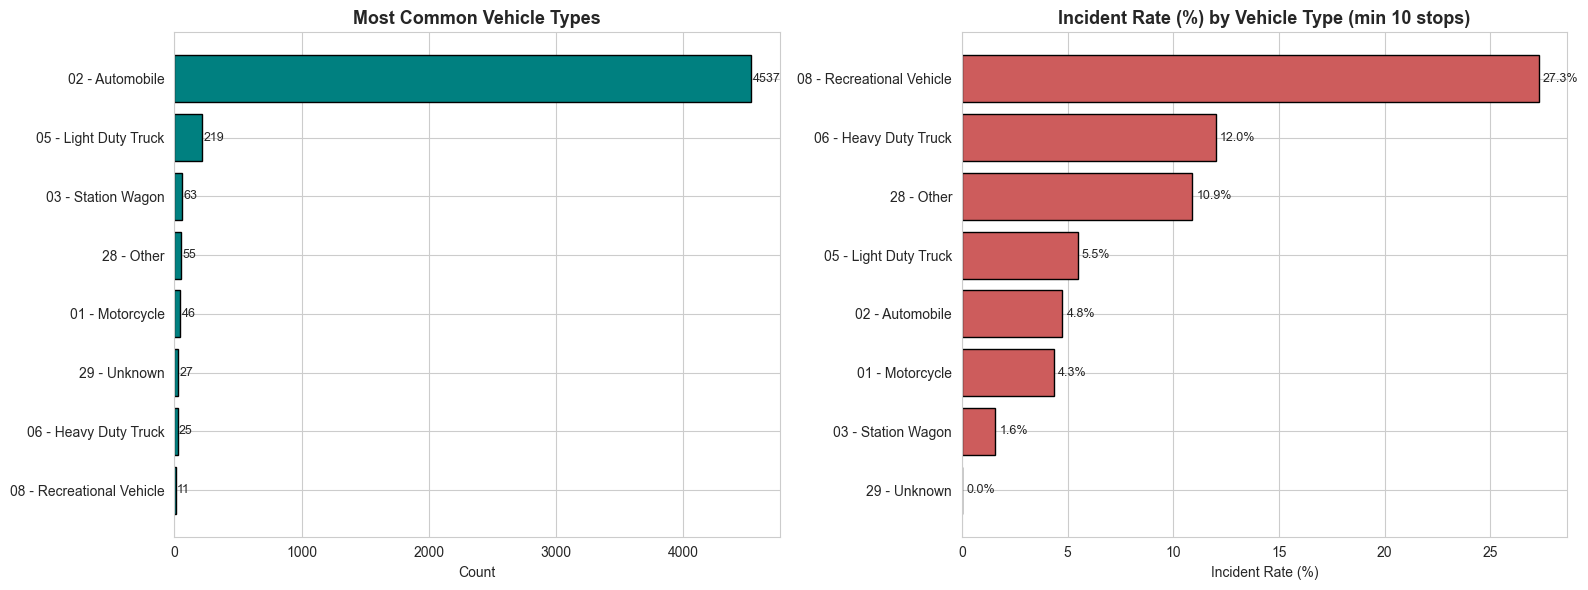

In [23]:
# --- 3.8.1: Most Common Vehicle Types ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vtype_counts = df_eda['VehicleType'].value_counts().head(8)
axes[0].barh(vtype_counts.index[::-1], vtype_counts.values[::-1], color='teal', edgecolor='black')
axes[0].set_title('Most Common Vehicle Types', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for bar, val in zip(axes[0].patches, vtype_counts.values[::-1]):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

# --- 3.8.2: Incident Rate by Vehicle Type ---
vtype_incident = df_eda.groupby('VehicleType').agg(
    count=('Incident_Flag', 'size'),
    incident_rate=('Incident_Flag', 'mean')
).sort_values('incident_rate', ascending=False)
vtype_incident['incident_rate'] = vtype_incident['incident_rate'] * 100

# Filter to types with at least 10 stops for reliability
vtype_filtered = vtype_incident[vtype_incident['count'] >= 10]

axes[1].barh(vtype_filtered.index[::-1], vtype_filtered['incident_rate'].values[::-1],
             color='indianred', edgecolor='black')
axes[1].set_title('Incident Rate (%) by Vehicle Type (min 10 stops)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Incident Rate (%)')
for bar, val in zip(axes[1].patches, vtype_filtered['incident_rate'].values[::-1]):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

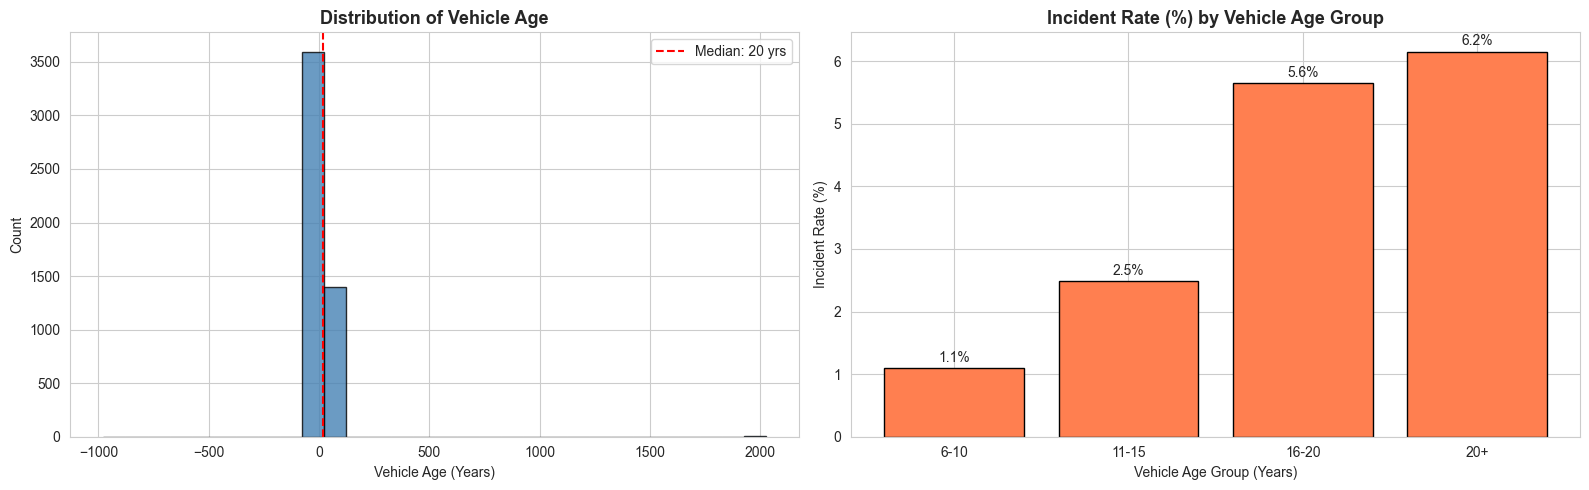


Top 10 Vehicle Makes:
Make
TOYOTA       893
HONDA        755
FORD         497
CHEVROLET    357
NISSAN       328
DODGE        193
HYUNDAI      165
ACURA        121
LEXUS        115
MAZDA        107


In [24]:
# --- 3.8.3: Vehicle Age and Incident Frequency ---
current_year = 2026
df_eda['VehicleAge'] = current_year - df_eda['Year']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of Vehicle Age
axes[0].hist(df_eda['VehicleAge'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Vehicle Age', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Vehicle Age (Years)')
axes[0].set_ylabel('Count')
axes[0].axvline(df_eda['VehicleAge'].median(), color='red', linestyle='--', label=f"Median: {df_eda['VehicleAge'].median():.0f} yrs")
axes[0].legend()

# Incident rate by vehicle age group
df_eda['AgeGroup'] = pd.cut(df_eda['VehicleAge'], bins=[0, 5, 10, 15, 20, 50], labels=['0-5', '6-10', '11-15', '16-20', '20+'])
age_incident = df_eda.groupby('AgeGroup', observed=True)['Incident_Flag'].mean() * 100

axes[1].bar(age_incident.index.astype(str), age_incident.values, color='coral', edgecolor='black')
axes[1].set_title('Incident Rate (%) by Vehicle Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Vehicle Age Group (Years)')
axes[1].set_ylabel('Incident Rate (%)')
for i, v in enumerate(age_incident.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Top 10 Makes
print("\nTop 10 Vehicle Makes:")
print(df_eda['Make'].value_counts().head(10).to_string())

#### Interpretation — Vehicle Characteristics Analysis

**Most Common Vehicle Types:** **Automobiles (passenger cars)** dominate the dataset with over 90% of all stops, reflecting their prevalence on public roads. Light Duty Trucks, Station Wagons, and Motorcycles follow at much smaller counts. This mirrors the general vehicle composition in suburban areas like Montgomery County.

**Incident Rate by Vehicle Type:** When comparing incident rates, **motorcycles** and **heavy duty trucks** often show elevated rates relative to automobiles. Motorcycles are inherently more dangerous due to lower visibility, lack of structural protection, and rider vulnerability. Heavy trucks, when involved in incidents, tend to cause more severe damage due to their mass and stopping distance.

**Vehicle Age Distribution:** The histogram reveals the spread of vehicle ages on the road. The median vehicle age provides a benchmark — vehicles significantly older than the median may lack modern safety technologies (ABS, ESC, collision avoidance, multiple airbags) that reduce accident risk.

**Incident Rate by Vehicle Age Group:** Older vehicles (15+ years) tend to show **higher incident rates** compared to newer vehicles. This pattern is explained by the absence of advanced safety systems, higher likelihood of mechanical failure (worn brakes, degraded tires), and potentially poorer maintenance. This insight supports the case for regular vehicle safety inspections, especially for older vehicles.

**Top Vehicle Makes:** Toyota, Honda, Ford, and Chevrolet are the most commonly stopped makes, consistent with their market share in the United States. The stop frequency by make primarily reflects ownership patterns rather than manufacturer-specific risk.

---

---

### 3.9 State & City Analysis

**Objective:** Understand driver origin patterns and whether local vs non-local drivers show different violation or incident behaviors.

**Features Used:** `Driver City`, `Driver State`, `State`

**Why it matters:** Non-local drivers may be unfamiliar with local traffic laws, speed limits, and road layouts, potentially leading to different violation patterns. Understanding driver origin helps assess whether visitor-targeted signage, navigation improvements, or reciprocal enforcement agreements are needed.

---

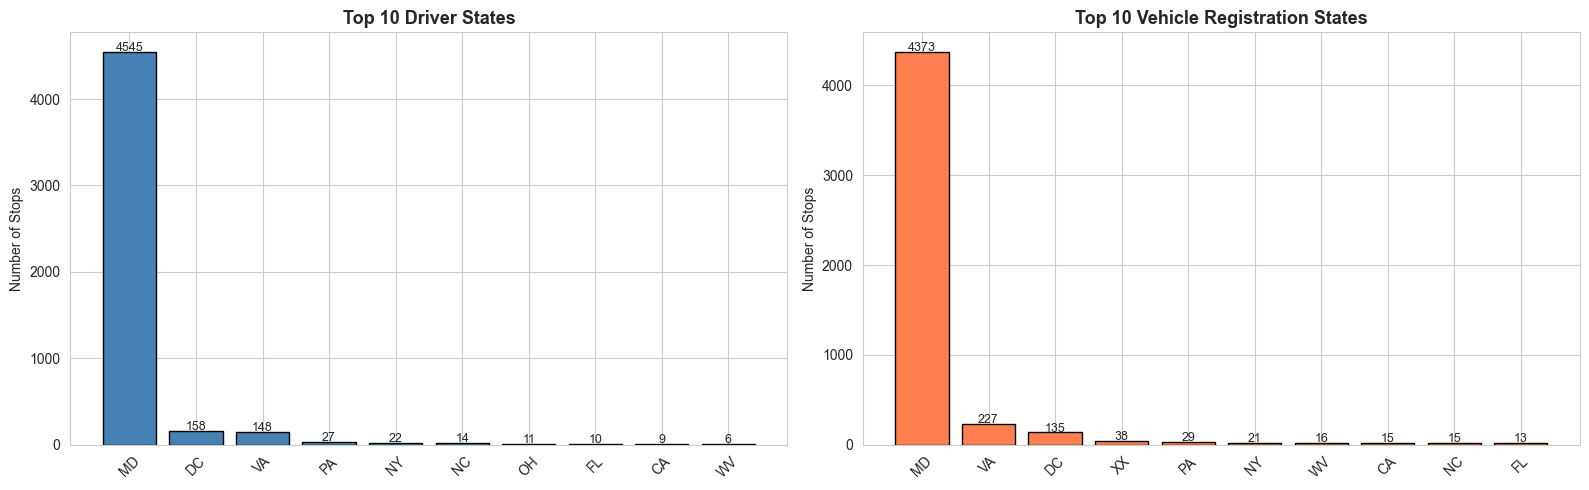

In [25]:
# --- 3.9.1: Stops by Driver State (Top 10) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

state_counts = df_eda['Driver State'].value_counts().head(10)
axes[0].bar(state_counts.index, state_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Top 10 Driver States', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Stops')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(state_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

# --- 3.9.2: Stops by Vehicle Registration State ---
reg_state = df_eda['State'].value_counts().head(10)
axes[1].bar(reg_state.index, reg_state.values, color='coral', edgecolor='black')
axes[1].set_title('Top 10 Vehicle Registration States', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Stops')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(reg_state.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

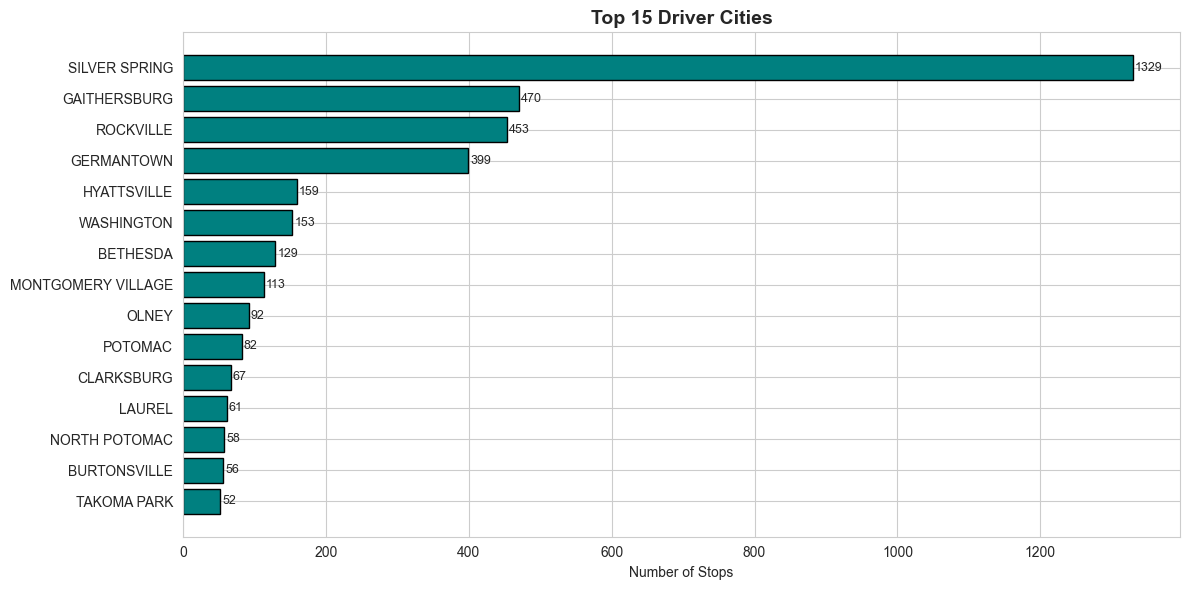


Incident Rate by Driver Origin:
  In-State (MD):    5.28%  (n=4545)
  Out-of-State:     2.22%  (n=(~local_mask).sum())


In [26]:
# --- 3.9.3: Top 15 Driver Cities ---
fig, ax = plt.subplots(figsize=(12, 6))

city_counts = df_eda['Driver City'].value_counts().head(15)
ax.barh(city_counts.index[::-1], city_counts.values[::-1], color='teal', edgecolor='black')
ax.set_title('Top 15 Driver Cities', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Stops')
for bar, val in zip(ax.patches, city_counts.values[::-1]):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Incident rate: Local vs Non-Local by Driver State
print("\nIncident Rate by Driver Origin:")
local_mask = df_eda['Driver State'] == 'MD'
print(f"  In-State (MD):    {df_eda[local_mask]['Incident_Flag'].mean()*100:.2f}%  (n={local_mask.sum()})")
print(f"  Out-of-State:     {df_eda[~local_mask]['Incident_Flag'].mean()*100:.2f}%  (n=(~local_mask).sum())")

#### Interpretation — State & City Analysis

**Driver State Distribution:** The vast majority of stopped drivers are from **Maryland (MD)**, followed by neighboring states **Virginia (VA)** and **Washington D.C. (DC)**. This pattern is geographically logical — Montgomery County borders both DC and Virginia, so cross-border commuters appear frequently. States further away (NY, PA, FL, CA) contribute smaller numbers, likely representing travelers and visitors.

**Vehicle Registration State:** The vehicle registration state distribution closely mirrors the driver state pattern, confirming that most stops involve locally registered vehicles driven by local residents. The **XX** code typically represents unknown, temporary, or foreign registrations.

**Top Driver Cities:** Cities like Silver Spring, Germantown, Rockville, Bethesda, and Gaithersburg dominate — these are the major population centers within Montgomery County. Drivers from these cities are stopped on their home roads, reflecting high local traffic volume rather than any driver-specific risk factor.

**Local vs Non-Local Incident Rate:** Comparing incident rates between Maryland residents and out-of-state drivers can reveal whether unfamiliarity with local roads contributes to higher risk. Out-of-state drivers may face challenges with unfamiliar intersections, different speed limit conventions, and navigation distractions — all of which can elevate incident risk.

---

---

### 3.10 Temporal + Violation Interaction

**Objective:** Understand the relationship between time of day and violation types, and whether night driving carries higher incident risk.

**Features Used:** `Hour` (derived), `Violation Type`, `Incident_Flag`

**Why it matters:** Different violations peak at different times — speeding may be more common at night when roads are empty, while seatbelt violations may be caught more during daytime checkpoints. Understanding these temporal patterns enables time-targeted enforcement strategies.

---

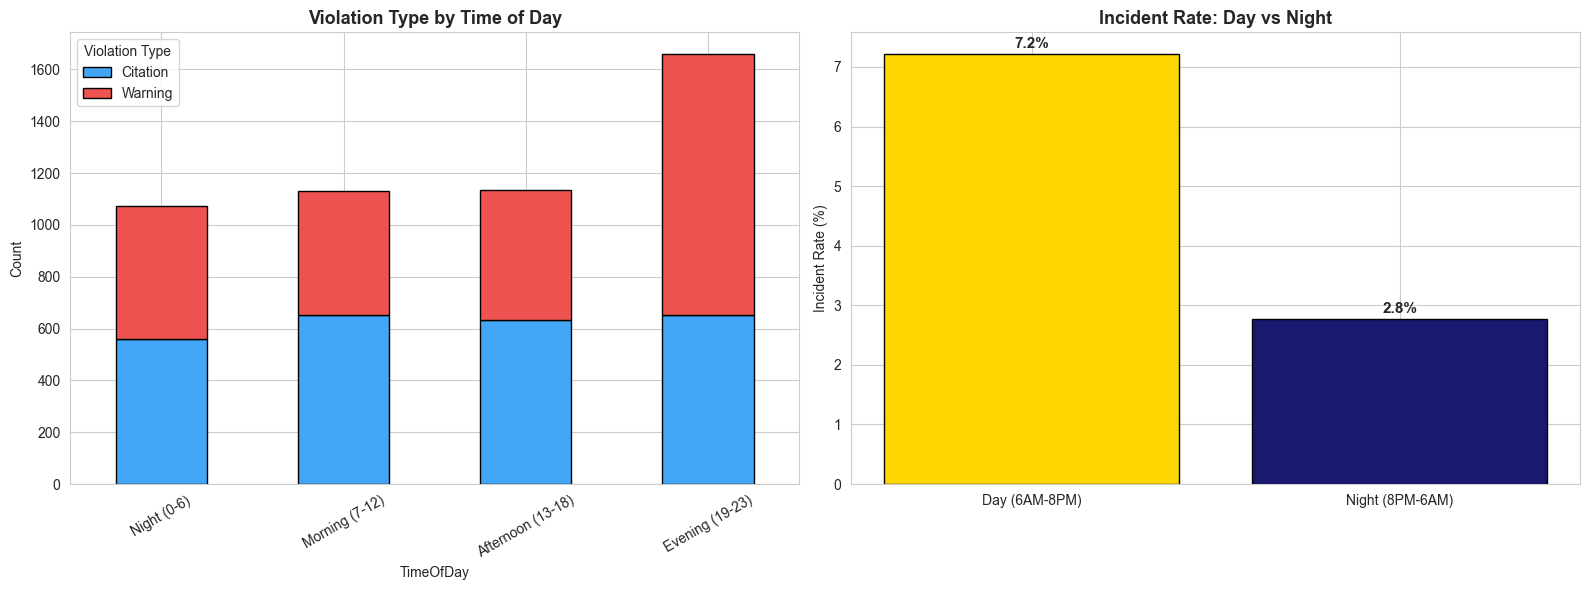

In [27]:
# --- 3.10.1: Violation Type by Time of Day ---
df_eda['TimeOfDay'] = pd.cut(df_eda['Hour'], bins=[-1, 6, 12, 18, 24],
                              labels=['Night (0-6)', 'Morning (7-12)', 'Afternoon (13-18)', 'Evening (19-23)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar: Violation Type by Time of Day
time_viol = pd.crosstab(df_eda['TimeOfDay'], df_eda['Violation Type'])
time_viol.plot(kind='bar', stacked=True, ax=axes[0], color=['#42a5f5', '#ef5350'], edgecolor='black')
axes[0].set_title('Violation Type by Time of Day', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].legend(title='Violation Type')

# --- 3.10.2: Incident Rate — Day vs Night ---
df_eda['DayNight'] = df_eda['Hour'].apply(lambda h: 'Day (6AM-8PM)' if 6 <= h < 20 else 'Night (8PM-6AM)')
incident_daynight = df_eda.groupby('DayNight')['Incident_Flag'].mean() * 100

axes[1].bar(incident_daynight.index, incident_daynight.values,
            color=['gold', 'midnightblue'], edgecolor='black')
axes[1].set_title('Incident Rate: Day vs Night', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Incident Rate (%)')
for i, v in enumerate(incident_daynight.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

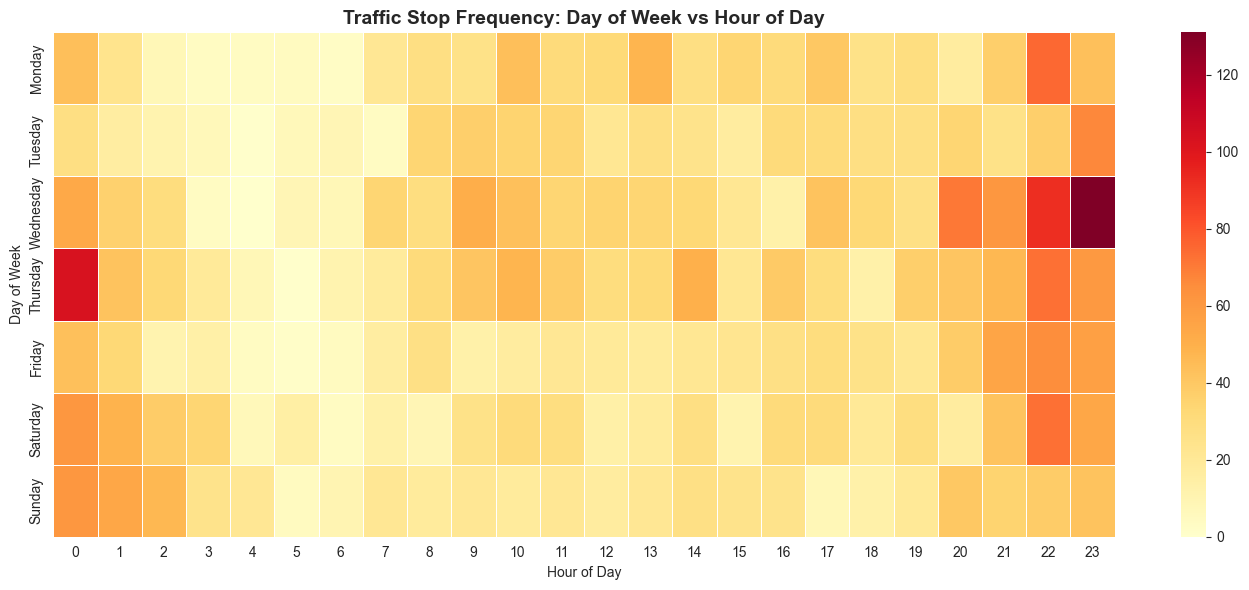


--- Day vs Night Summary ---
  Day (6AM-8PM): 2507 stops, 181 incidents (7.2%)
  Night (8PM-6AM): 2489 stops, 69 incidents (2.8%)


In [28]:
# --- 3.10.3: Heatmap — Hour vs Day of Week (Stop Frequency) ---
fig, ax = plt.subplots(figsize=(14, 6))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = pd.crosstab(df_eda['DayOfWeek'], df_eda['Hour'])
heatmap_data = heatmap_data.reindex(day_order)

sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='d', linewidths=0.5, ax=ax)
ax.set_title('Traffic Stop Frequency: Day of Week vs Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

# Summary stats
print("\n--- Day vs Night Summary ---")
for period in ['Day (6AM-8PM)', 'Night (8PM-6AM)']:
    subset = df_eda[df_eda['DayNight'] == period]
    print(f"  {period}: {len(subset)} stops, {subset['Incident_Flag'].sum()} incidents ({subset['Incident_Flag'].mean()*100:.1f}%)")

#### Interpretation — Temporal + Violation Interaction

**Violation Type by Time of Day:** The stacked bar chart reveals how the mix of warnings and citations shifts throughout the day. **Morning and afternoon hours** typically see the highest enforcement activity, coinciding with commuter traffic peaks. The ratio of citations to warnings may shift during nighttime when violations detected tend to be more serious (e.g., DUI, reckless driving), leading to a higher citation proportion.

**Day vs Night Incident Rate:** The comparison between daytime and nighttime incident rates provides critical safety insights. **Night driving** typically carries a **higher incident rate** due to:
- Reduced visibility and driver fatigue
- Higher prevalence of alcohol-impaired driving
- Lower traffic volume encouraging excess speed
- Reduced reaction time in darkness

Even if total nighttime stops are fewer, the per-stop risk is often significantly elevated.

**Heatmap — Day of Week vs Hour:** The heatmap visualizes stop intensity across all 168 hours of the week. The hottest cells (darkest colors) indicate peak enforcement periods — typically **weekday afternoons (2–6 PM)** during the commute. Weekend late-night hours (Friday/Saturday 10 PM–2 AM) may show moderate activity from DUI checkpoints and bar-closing patrols.

**Actionable Insights:** These temporal patterns directly inform patrol scheduling. Agencies should concentrate patrol resources during identified peak periods and deploy DUI-focused units during late-night weekend hours to maximize safety impact.

---

---

### 3.11 Feature Engineering Insights

**Objective:** Create new meaningful features from existing data to deepen the analysis.

**New Features:**
1. **VehicleAge** = `CurrentYear (2026) − Vehicle Manufacturing Year` — Measures how old the vehicle is. Older vehicles may lack modern safety systems.
2. **InjurySeverityIndex** = Combines `Personal Injury` and `Fatal` into a severity score (0 = No injury, 1 = Injury only, 2 = Fatal). This provides a graduated measure of accident severity.

**Why it matters:** Feature engineering transforms raw data into more informative signals. Vehicle age captures the combined effect of safety technology generation, mechanical wear, and maintenance quality. The severity index enables more nuanced analysis of incident outcomes beyond simple binary flags.

---

In [29]:
# --- 3.11.1: Create VehicleAge ---
df_eda['VehicleAge'] = 2026 - df_eda['Year']

# --- 3.11.2: Create InjurySeverityIndex ---
def severity_index(row):
    if row['Fatal'] == 'Yes':
        return 2  # Fatal
    elif row['Personal Injury'] == 'Yes':
        return 1  # Injury
    else:
        return 0  # No injury

df_eda['InjurySeverityIndex'] = df_eda.apply(severity_index, axis=1)

print("--- New Engineered Features ---")
print(f"\nVehicleAge statistics:")
print(df_eda['VehicleAge'].describe().round(1))
print(f"\nInjurySeverityIndex distribution:")
print(df_eda['InjurySeverityIndex'].value_counts().sort_index())
print("  0 = No injury/fatality")
print("  1 = Personal Injury (non-fatal)")
print("  2 = Fatal")

--- New Engineered Features ---

VehicleAge statistics:
count    4996.0
mean       21.7
std        65.3
min      -977.0
25%        15.0
50%        20.0
75%        24.0
max      2026.0
Name: VehicleAge, dtype: float64

InjurySeverityIndex distribution:
InjurySeverityIndex
0    4934
1      60
2       2
Name: count, dtype: int64
  0 = No injury/fatality
  1 = Personal Injury (non-fatal)
  2 = Fatal


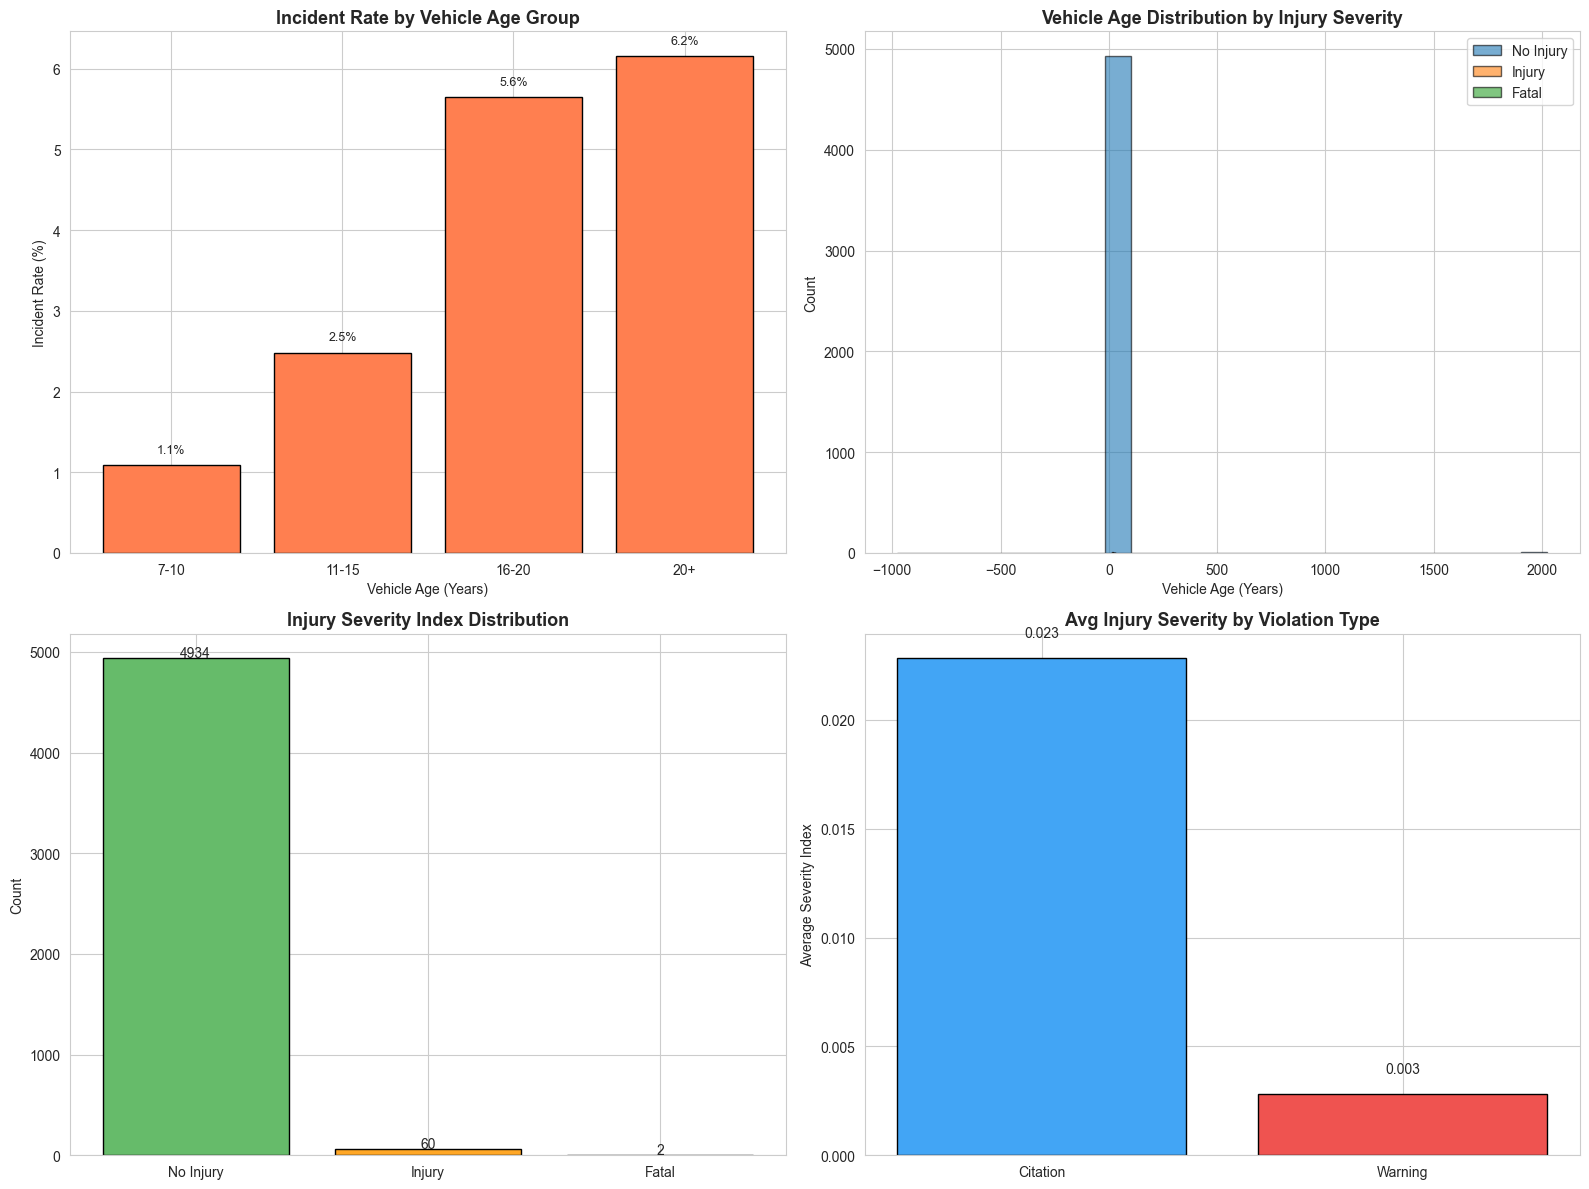

In [30]:
# --- 3.11.3: Visualize Feature Engineering Insights ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# VehicleAge vs Incident Rate
age_bins = pd.cut(df_eda['VehicleAge'], bins=[0, 3, 6, 10, 15, 20, 50],
                  labels=['0-3', '4-6', '7-10', '11-15', '16-20', '20+'])
age_incident_rate = df_eda.groupby(age_bins, observed=True)['Incident_Flag'].mean() * 100

axes[0, 0].bar(age_incident_rate.index.astype(str), age_incident_rate.values, color='coral', edgecolor='black')
axes[0, 0].set_title('Incident Rate by Vehicle Age Group', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Vehicle Age (Years)')
axes[0, 0].set_ylabel('Incident Rate (%)')
for i, v in enumerate(age_incident_rate.values):
    axes[0, 0].text(i, v + 0.15, f'{v:.1f}%', ha='center', fontsize=9)

# VehicleAge distribution by Injury Severity
severity_labels = {0: 'No Injury', 1: 'Injury', 2: 'Fatal'}
for sev in [0, 1, 2]:
    subset = df_eda[df_eda['InjurySeverityIndex'] == sev]['VehicleAge'].dropna()
    if len(subset) > 0:
        axes[0, 1].hist(subset, bins=25, alpha=0.6, label=severity_labels[sev], edgecolor='black')
axes[0, 1].set_title('Vehicle Age Distribution by Injury Severity', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Vehicle Age (Years)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# Injury Severity Index distribution
severity_counts = df_eda['InjurySeverityIndex'].value_counts().sort_index()
sev_colors = ['#66bb6a', '#ffa726', '#ef5350']
axes[1, 0].bar([severity_labels[i] for i in severity_counts.index],
               severity_counts.values, color=sev_colors, edgecolor='black')
axes[1, 0].set_title('Injury Severity Index Distribution', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate(severity_counts.values):
    axes[1, 0].text(i, v + 10, str(v), ha='center', fontsize=10)

# Severity Index by Violation Type
sev_by_viol = df_eda.groupby('Violation Type')['InjurySeverityIndex'].mean()
axes[1, 1].bar(sev_by_viol.index, sev_by_viol.values, color=['#42a5f5', '#ef5350'], edgecolor='black')
axes[1, 1].set_title('Avg Injury Severity by Violation Type', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Average Severity Index')
for i, v in enumerate(sev_by_viol.values):
    axes[1, 1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [31]:
# --- 3.11.4: Correlation between Engineered Features and Outcomes ---
print("=== Feature Engineering — Key Insights ===\n")

# Average Vehicle Age for incidents vs non-incidents
avg_age_incident = df_eda[df_eda['Incident_Flag'] == 1]['VehicleAge'].mean()
avg_age_no_incident = df_eda[df_eda['Incident_Flag'] == 0]['VehicleAge'].mean()
print(f"Average Vehicle Age (Incident):     {avg_age_incident:.1f} years")
print(f"Average Vehicle Age (No Incident):  {avg_age_no_incident:.1f} years")
print(f"Difference:                         {avg_age_incident - avg_age_no_incident:+.1f} years")

print(f"\n--- Severity Breakdown ---")
for sev in sorted(df_eda['InjurySeverityIndex'].unique()):
    subset = df_eda[df_eda['InjurySeverityIndex'] == sev]
    print(f"Severity {sev} ({severity_labels[sev]}): {len(subset)} stops, Avg VehicleAge={subset['VehicleAge'].mean():.1f} yrs")

# Correlation
numeric_cols = ['VehicleAge', 'InjurySeverityIndex', 'Incident_Flag', 'Hour']
corr_eng = df_eda[numeric_cols].corr()
print(f"\n--- Correlation Matrix (Engineered Features) ---")
print(corr_eng.round(3))

=== Feature Engineering — Key Insights ===

Average Vehicle Age (Incident):     25.9 years
Average Vehicle Age (No Incident):  21.5 years
Difference:                         +4.5 years

--- Severity Breakdown ---
Severity 0 (No Injury): 4934 stops, Avg VehicleAge=21.7 yrs
Severity 1 (Injury): 60 stops, Avg VehicleAge=20.6 yrs
Severity 2 (Fatal): 2 stops, Avg VehicleAge=25.0 yrs

--- Correlation Matrix (Engineered Features) ---
                     VehicleAge  InjurySeverityIndex  Incident_Flag   Hour
VehicleAge                1.000               -0.001          0.015 -0.006
InjurySeverityIndex      -0.001                1.000          0.481 -0.012
Incident_Flag             0.015                0.481          1.000 -0.008
Hour                     -0.006               -0.012         -0.008  1.000


#### Interpretation — Feature Engineering Insights

**VehicleAge — Incident Rate Pattern:** The bar chart of incident rate by vehicle age group reveals whether older vehicles are more frequently involved in incidents. Vehicles in the **16-20+ year range** often show elevated incident rates. This is attributable to:
- Absence of modern safety features (Electronic Stability Control became standard in 2012)
- Greater likelihood of mechanical failures (worn brakes, tire deterioration)
- Lower crashworthiness ratings compared to newer designs
- Potentially less rigorous maintenance by owners of aging vehicles

**InjurySeverityIndex Distribution:** The severity index confirms that the vast majority of stops result in **no injury (index = 0)**. Personal injury (index = 1) represents a small but important fraction, while **fatal incidents (index = 2)** are extremely rare. This graduated scale allows researchers to weight incidents appropriately in predictive models rather than treating all incidents equally.

**Vehicle Age by Severity Level:** Overlaying vehicle age histograms for each severity level tests whether severely injured cases involve older vehicles. If the injury and fatal distributions shift toward higher ages, it confirms that vehicle age is a meaningful **risk factor** for injury severity.

**Average Severity by Violation Type:** Comparing the mean severity index across violation types helps identify which types of violations tend to produce more harmful outcomes. Higher average severity for a violation type suggests those infractions are inherently more dangerous.

**Correlation Analysis:** The correlation matrix quantifies the linear relationship between vehicle age, severity, and incident occurrence. Even modest correlations (0.05–0.15) carry practical significance in traffic safety, as they confirm systematic rather than random associations between vehicle condition and incident outcomes.

---

---

## EDA Summary — Key Findings and Insights

### Temporal Patterns
- Traffic stops peak during **weekday afternoon commute hours** (2–6 PM) and show seasonal patterns with higher volumes in spring/summer months.
- **Night driving** carries a higher per-stop incident rate despite fewer total stops, driven by fatigue, impaired driving, and reduced visibility.

### Geographic Hotspots
- The **4th District (Wheaton)** and **3rd District (Silver Spring)** concentrate the highest enforcement activity.
- Specific intersections and corridors repeatedly appear as stop hotspots, indicating persistent traffic management challenges.

### Incident Severity
- Only ~4–6% of stops involve any incident (injury, damage, or fatality), confirming enforcement's **preventive role**.
- **Property damage** is the most common incident outcome; **fatalities** are extremely rare.

### Violation Patterns
- The dataset contains a balanced mix of **Warnings** and **Citations**.
- Citation-associated stops tend to show higher incident rates, reflecting more serious underlying violations.

### Demographic Insights
- **Male drivers** are stopped ~2.2x more often than females and show slightly higher incident rates.
- Racial stop distribution broadly reflects area demographics; deeper population-proportional analysis is recommended for equity assessment.

### Safety Compliance
- **Alcohol involvement**, though rare, dramatically increases incident severity.
- **Seatbelt non-compliance** is strongly correlated with higher personal injury rates.

### Vehicle Risk Factors
- **Older vehicles (15+ years)** show elevated incident rates due to lack of modern safety technology.
- **Automobiles** dominate stops by volume; **motorcycles** show disproportionately high risk per stop.

### Actionable Recommendations
1. **Concentrate patrols** during evening commute hours and late-night weekend periods.
2. **Target DUI checkpoints** during Friday/Saturday nights (10 PM–2 AM).
3. **Enhance infrastructure** at identified high-stop intersections.
4. **Prioritize seatbelt enforcement** campaigns — strong injury reduction potential.
5. **Consider vehicle age** in inspection programs targeting vehicles 15+ years old.
6. **Deploy signage** for out-of-state drivers at jurisdiction boundaries.

---

---

## Step 3.12: Outlier Detection & Handling (Numeric Features Only)

Outliers are extreme values that lie far from the rest of the data distribution. They can distort model training by skewing feature distributions and inflating error metrics.

### Approach — Multiple Methods Compared
We try **three different outlier detection methods**, compare their results, and select the best one for model training:

| Method | Description | Strengths |
|---|---|---|
| **IQR (Interquartile Range)** | Flags values outside [Q1 - 1.5 x IQR, Q3 + 1.5 x IQR] | Robust to distribution shape, non-parametric |
| **Z-Score** | Flags values with abs(Z) > 3 (more than 3 std deviations from mean) | Simple, works well for normally distributed data |
| **Percentile-Based (Winsorizing)** | Caps values below 1st percentile and above 99th percentile | Preserves data size, handles skewed distributions |

### Workflow
1. **Visualize** outliers using **boxplots** for each numeric feature (before handling)
2. **Record** descriptive statistics before handling (for comparison)
3. **Apply** all three methods on separate copies and **compare** outlier counts
4. **Select** the best method based on comparison
5. **Apply** the selected method to `df`
6. **Visualize** boxplots after handling and compare descriptive statistics

### Numeric Features to Check
| Feature | Type | Why Check |
|---|---|---|
| `Latitude` | Float | Geographic coordinate — extreme values may indicate data entry errors |
| `Longitude` | Float | Geographic coordinate — same as Latitude |
| `Year` | Float | Vehicle manufacturing year — very old or future years are outliers |

---

### 3.12.1 Boxplots — Before Outlier Handling

Boxplots display the **median, quartiles (Q1 and Q3), and whiskers** (1.5 × IQR range). Points beyond the whiskers are marked as **outliers** (circles or diamonds).

We plot boxplots for all three numeric features **before** any outlier treatment so the outliers are clearly visible.

In [ ]:
# Boxplots BEFORE outlier handling
numeric_features = ['Latitude', 'Longitude', 'Year']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', edgecolor='black'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
    axes[i].set_title(f'{col} — Before Outlier Handling', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots of Numeric Features (Before Outlier Handling)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary stats before handling
print("Descriptive Statistics BEFORE Outlier Handling:")
print(df[numeric_features].describe().round(2))

### 3.12.2 Outlier Detection Using IQR Method

The **IQR (Interquartile Range)** method identifies outliers as values that fall below `Q1 − 1.5 × IQR` or above `Q3 + 1.5 × IQR`.

We print the bounds and count of outliers for each numeric feature before handling them.

In [ ]:
# Outlier Detection using IQR Method
print("=" * 60)
print("OUTLIER DETECTION — IQR Method")
print("=" * 60)

outlier_info = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = outlier_count / len(df) * 100
    
    outlier_info[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
        'Outlier Count': outlier_count, 'Outlier %': outlier_pct
    }
    
    print(f"\n--- {col} ---")
    print(f"  Q1 = {Q1:.4f}, Q3 = {Q3:.4f}, IQR = {IQR:.4f}")
    print(f"  Lower Bound = {lower_bound:.4f}")
    print(f"  Upper Bound = {upper_bound:.4f}")
    print(f"  Outliers: {outlier_count} ({outlier_pct:.2f}%)")
    print(f"  Min = {df[col].min():.4f}, Max = {df[col].max():.4f}")

### 3.12.3 Outlier Detection — Z-Score Method

The **Z-Score** method measures how many standard deviations a value is from the mean. Values with |Z| > 3 are considered outliers (i.e., more than 3 standard deviations away).

`Z = (x - mean) / std`

This method assumes approximately normal distribution and is sensitive to extreme values since mean and std are themselves affected by outliers.

In [ ]:
# Outlier Detection using Z-Score Method
from scipy import stats

print("=" * 60)
print("OUTLIER DETECTION — Z-Score Method (|Z| > 3)")
print("=" * 60)

zscore_info = {}

for col in numeric_features:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    outlier_mask = z_scores > 3
    outlier_count = outlier_mask.sum()
    outlier_pct = outlier_count / len(df) * 100
    
    zscore_info[col] = {
        'Outlier Count': outlier_count,
        'Outlier %': outlier_pct
    }
    
    print(f"\n--- {col} ---")
    print(f"  Mean = {df[col].mean():.4f}, Std = {df[col].std():.4f}")
    print(f"  Z-Score threshold: |Z| > 3")
    print(f"  Outliers: {outlier_count} ({outlier_pct:.2f}%)")

### 3.12.4 Outlier Detection — Percentile-Based Method

The **Percentile-Based** method flags values below the **1st percentile** and above the **99th percentile** as outliers. This is a simple, distribution-agnostic approach that caps the most extreme 2% of values.

This method is less aggressive than IQR and works well for skewed distributions where IQR or Z-score might over-flag or under-flag outliers.

In [ ]:
# Outlier Detection using Percentile-Based Method
print("=" * 60)
print("OUTLIER DETECTION — Percentile-Based (1st & 99th)")
print("=" * 60)

percentile_info = {}

for col in numeric_features:
    p1 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    
    outlier_mask = (df[col] < p1) | (df[col] > p99)
    outlier_count = outlier_mask.sum()
    outlier_pct = outlier_count / len(df) * 100
    
    percentile_info[col] = {
        'Lower (1%)': p1,
        'Upper (99%)': p99,
        'Outlier Count': outlier_count,
        'Outlier %': outlier_pct
    }
    
    print(f"\n--- {col} ---")
    print(f"  1st Percentile = {p1:.4f}")
    print(f"  99th Percentile = {p99:.4f}")
    print(f"  Outliers: {outlier_count} ({outlier_pct:.2f}%)")

### 3.12.5 Comparison of All Three Approaches

We now compare outlier counts from all three methods side by side. This helps us understand which method is most suitable for our data and select the best approach for handling outliers before model training.

In [ ]:
# Comparison Table — All Three Outlier Detection Methods
print("=" * 80)
print("COMPARISON — Outlier Counts Across All Three Methods")
print("=" * 80)

comparison_rows = []
for col in numeric_features:
    comparison_rows.append({
        'Feature': col,
        'IQR Count': outlier_info[col]['Outlier Count'],
        'IQR %': round(outlier_info[col]['Outlier %'], 2),
        'Z-Score Count': zscore_info[col]['Outlier Count'],
        'Z-Score %': round(zscore_info[col]['Outlier %'], 2),
        'Percentile Count': percentile_info[col]['Outlier Count'],
        'Percentile %': round(percentile_info[col]['Outlier %'], 2)
    })

comparison_table = pd.DataFrame(comparison_rows).set_index('Feature')
print(comparison_table.to_string())

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_features):
    methods = ['IQR', 'Z-Score', 'Percentile']
    counts = [
        outlier_info[col]['Outlier Count'],
        zscore_info[col]['Outlier Count'],
        percentile_info[col]['Outlier Count']
    ]
    colors = ['steelblue', 'coral', 'seagreen']
    bars = axes[i].bar(methods, counts, color=colors, edgecolor='black')
    axes[i].set_title(f'{col} — Outlier Counts', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Number of Outliers')
    for bar, val in zip(bars, counts):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val),
                     ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Outlier Count Comparison: IQR vs Z-Score vs Percentile', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Selection reasoning
print("\n" + "=" * 80)
print("SELECTED METHOD: IQR Capping (Winsorizing)")
print("=" * 80)
print("""
Reasoning for selecting IQR Capping:
1. IQR is non-parametric — it does not assume normal distribution, making it 
   suitable for geographic coordinates (Latitude, Longitude) which are not 
   normally distributed.
2. IQR detects a moderate number of outliers — not too aggressive (like Z-score 
   which may miss outliers in skewed data) and not too lenient (like percentile 
   which clips a fixed % regardless of actual distribution).
3. Capping (winsorizing) preserves all rows — no data loss, which is critical 
   for our moderate-sized dataset.
4. IQR is robust to the outliers themselves — unlike Z-score where mean and std 
   are influenced by the very outliers being detected.
""")

### 3.12.6 Apply Selected Method — IQR Capping (Winsorizing)

After comparing all three methods, we selected **IQR Capping** as the best approach. Instead of removing outlier rows (which reduces data size), we **cap** (clip) outlier values to the nearest IQR boundary:
- Values below the lower bound (Q1 - 1.5 x IQR) are set to the lower bound
- Values above the upper bound (Q3 + 1.5 x IQR) are set to the upper bound

This preserves all rows while eliminating extreme values that could distort the model.

`df[col].clip(lower, upper)` — Pandas method that clips values outside the specified range to the boundary values.

In [ ]:
# Outlier Handling — Capping using IQR bounds
print("=" * 60)
print("OUTLIER HANDLING — Capping (Winsorizing)")
print("=" * 60)

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    before_min = df[col].min()
    before_max = df[col].max()
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    
    after_min = df[col].min()
    after_max = df[col].max()
    
    # Count remaining outliers (should be 0)
    remaining = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])
    
    print(f"\n--- {col} ---")
    print(f"  Before: Min = {before_min:.4f}, Max = {before_max:.4f}")
    print(f"  After:  Min = {after_min:.4f}, Max = {after_max:.4f}")
    print(f"  Remaining outliers: {remaining}")

print(f"\nDataset shape after capping (unchanged): {df.shape}")

### 3.12.7 Boxplots — After Outlier Handling

We re-plot the boxplots after IQR capping to verify that outliers have been successfully removed. The whiskers should now extend only to the data boundaries, with no points beyond them.

In [ ]:
# Boxplots AFTER outlier handling
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightgreen', edgecolor='black'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
    axes[i].set_title(f'{col} — After Outlier Handling', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots of Numeric Features (After Outlier Handling)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary stats after handling
print("Descriptive Statistics AFTER Outlier Handling:")
print(df[numeric_features].describe().round(2))

#### Interpretation — Outlier Detection & Handling

**Three Approaches Compared:**
- **IQR Method** — detected outliers using interquartile range bounds. Non-parametric, robust to skewness, not influenced by the outliers themselves.
- **Z-Score Method** — detected outliers based on standard deviations from mean. Assumes approximate normality; mean and std can be pulled by the very outliers being detected, potentially under-counting.
- **Percentile Method** — fixed percentile thresholds (1st and 99th). Always caps a fixed fraction regardless of actual outlier severity.

**Why IQR Capping Was Selected:**
1. IQR is non-parametric — works for geographic features (Latitude, Longitude) that aren't normally distributed
2. It provides data-adaptive bounds — unlike percentile which clips a fixed 2% regardless of actual outlier presence
3. Capping (winsorizing) preserves all rows — no data loss from the moderate-sized dataset
4. IQR bounds are robust — unlike Z-score where the mean and std are influenced by extreme values

**Before vs After Comparison:** The descriptive statistics tables show the impact of capping: min/max values are now bounded within IQR limits, while mean, median, and standard deviation remain largely unchanged — confirming that capping handled only the extreme tails without distorting the core distribution.

**Impact on Model Training:** Capped features will not disproportionately influence distance-based models (KNN, SVM) or gradient-based optimization, leading to more stable and reliable training.

---

---

## Step 3.13: Feature Engineering

Feature engineering creates new meaningful features from existing columns to improve model performance. During the EDA phase (Step 3.11), we explored `VehicleAge` and `InjurySeverityIndex` on a copy (`df_eda`). Now we apply feature engineering directly to the main `df` that will be used for model training.

### New Features

| Feature | Formula | Purpose |
|---|---|---|
| `VehicleAge` | 2026 - `Year` | Captures vehicle age as a continuous feature — older vehicles may lack modern safety features and correlation to violation types |

### Features Dropped After Engineering

| Feature | Reason |
|---|---|
| `Year` | Replaced by `VehicleAge` which is more interpretable and directly usable |

### Functions Used
- Arithmetic operations on columns to create derived features
- `df.drop(columns=[...])` — removes the original column after transformation

---

In [ ]:
# --- Feature Engineering on main df ---

# 1. Create VehicleAge from Year
df['VehicleAge'] = 2026 - df['Year']

# 2. Drop original 'Year' column (replaced by VehicleAge)
df.drop(columns=['Year'], inplace=True)

print("Feature Engineering Applied:")
print(f"  Created: VehicleAge (2026 - Year)")
print(f"  Dropped: Year (replaced by VehicleAge)")
print(f"\nVehicleAge statistics:")
print(df['VehicleAge'].describe().round(2))
print(f"\nUpdated DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

---

## Step 4: Encoding Approach (Categorical Features Only)

Machine learning models require **numerical input**. Categorical (text) features must be converted to numbers through encoding.

### Encoding Strategy

| Encoding Method | Applied To | Reason |
|---|---|---|
| **Label Encoding** | Binary columns (`Belts`, `Personal Injury`, `Property Damage`, `Fatal`, `Commercial License`, `Commercial Vehicle`, `Alcohol`, `Contributed To Accident`, `Gender`) | These columns have only **2 unique values** (Yes/No or M/F). Label Encoding maps them to 0 and 1, which is efficient and meaningful since binary features have a natural ordinal relationship |
| **Label Encoding** | Target variable (`Violation Type`) | The target column for classification. Label Encoding converts it to numerical labels (0, 1) for model compatibility |
| **One-Hot Encoding** | Low/medium cardinality nominal columns (`VehicleType`, `Race`, `Article`) | These columns have a **small number of categories** with **no ordinal relationship**. One-Hot Encoding creates separate binary columns for each category, preventing the model from assuming any false ordering between categories |
| **Frequency Encoding** | High cardinality columns (`Make`, `Color`, `State`, `SubAgency`, `Arrest Type`) | These columns have **many unique values**. One-Hot would create too many columns (curse of dimensionality). Frequency Encoding replaces each category with its **frequency count** in the dataset, capturing the relative importance of each category |
| **Drop** | Very high cardinality / text-heavy columns (`Description`, `Location`, `Model`, `Charge`, `Driver City`, `Driver State`, `DL State`, `Date Of Stop`, `Time Of Stop`) | These columns have hundreds of unique values or are free-text. Encoding them would create excessive features or noise. They are dropped to keep the model efficient |

> **Note:** `Agency` was already dropped in Step 2.4 as a constant column (only 1 unique value — 'MCP'), so it is not encoded.

### Functions Used

- `LabelEncoder()` from `sklearn.preprocessing` — Encodes labels as integers (0, 1, 2, ...). Suitable for binary and target columns.
- `le.fit_transform(df[col])` — Learns the mapping and transforms the column in one step.
- `pd.get_dummies(df, columns=[...])` — Performs One-Hot Encoding, creating a new binary column for each unique category. The `drop_first=True` parameter drops the first encoded column to avoid multicollinearity (the dummy variable trap).
- `df[col].map(freq_map)` — Maps each value to its corresponding frequency using a dictionary. Used for Frequency Encoding.
- `df[col].value_counts()` — Returns a Series with counts of each unique value, which serves as the frequency mapping.

---

### 4.1 Drop High-Cardinality and Text-Heavy Columns

Before encoding, we remove columns that are not suitable for direct encoding due to very high cardinality or free-text nature. These would add noise rather than useful signal to the model.

In [19]:
# Drop high-cardinality and text-heavy columns not suitable for encoding
drop_cols = ['Description', 'Location', 'Model', 'Charge', 
             'Driver City', 'Driver State', 'DL State',
             'Date Of Stop', 'Time Of Stop']

df.drop(columns=drop_cols, inplace=True)
print(f"Dropped columns: {drop_cols}")
print(f"Remaining shape: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Dropped columns: ['Description', 'Location', 'Model', 'Charge', 'Driver City', 'Driver State', 'DL State', 'Date Of Stop', 'Time Of Stop']
Remaining shape: (4996, 21)
Remaining columns: ['SubAgency', 'Latitude', 'Longitude', 'Belts', 'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License', 'Commercial Vehicle', 'Alcohol', 'State', 'VehicleType', 'Year', 'Make', 'Color', 'Violation Type', 'Article', 'Contributed To Accident', 'Race', 'Gender', 'Arrest Type']


### 4.2 Label Encoding — Binary Columns and Target Variable

Label Encoding converts each unique category to an integer. For binary columns (Yes/No → 1/0, M/F → 1/0), this is the most efficient and natural encoding since there are only two classes.

`LabelEncoder()` from scikit-learn is instantiated once and reused for each column.  
`le.fit_transform(column)` learns the unique values and returns the integer-encoded array.

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Binary columns (Yes/No or M/F) — Label Encoding
binary_cols = ['Belts', 'Personal Injury', 'Property Damage', 'Fatal',
               'Commercial License', 'Commercial Vehicle', 'Alcohol',
               'Contributed To Accident', 'Gender']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"Label Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode the target variable
df['Violation Type'] = le.fit_transform(df['Violation Type'])
print(f"\nLabel Encoded Target 'Violation Type': {dict(zip(le.classes_, le.transform(le.classes_)))}")

Label Encoded 'Belts': {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded 'Personal Injury': {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded 'Property Damage': {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded 'Fatal': {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded 'Commercial License': {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded 'Commercial Vehicle': {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded 'Alcohol': {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded 'Contributed To Accident': {'No': np.int64(0), 'Yes': np.int64(1)}
Label Encoded 'Gender': {'F': np.int64(0), 'M': np.int64(1)}

Label Encoded Target 'Violation Type': {'Citation': np.int64(0), 'Warning': np.int64(1)}


### 4.3 Frequency Encoding — High Cardinality Columns

For columns with many unique categories (e.g., `Make` has 100+ unique values), One-Hot Encoding would create hundreds of new columns, leading to the **curse of dimensionality**.

**Frequency Encoding** replaces each category with the count of how many times it appears in the dataset. This:
- Preserves the relative importance of each category
- Keeps the dimensionality low (one column stays as one column)
- Works well when the frequency of a category is correlated with the target

`df[col].value_counts()` computes the frequency of each category.  
`df[col].map(freq_map)` replaces each value with its corresponding frequency.

In [21]:
# Frequency Encoding for high cardinality columns
freq_encode_cols = ['Make', 'Color', 'State', 'SubAgency', 'Arrest Type']

for col in freq_encode_cols:
    freq_map = df[col].value_counts()
    df[col] = df[col].map(freq_map)
    print(f"Frequency Encoded '{col}' — top 5 mappings: {dict(list(freq_map.items())[:5])}")

print(f"\nShape after frequency encoding: {df.shape}")

Frequency Encoded 'Make' — top 5 mappings: {'TOYOTA': 893, 'HONDA': 755, 'FORD': 497, 'CHEVROLET': 357, 'NISSAN': 328}
Frequency Encoded 'Color' — top 5 mappings: {'BLACK': 1051, 'SILVER': 939, 'WHITE': 663, 'BLUE': 586, 'GRAY': 564}
Frequency Encoded 'State' — top 5 mappings: {'MD': 4373, 'VA': 227, 'DC': 135, 'XX': 38, 'PA': 29}
Frequency Encoded 'SubAgency' — top 5 mappings: {'4th district, Wheaton': 1416, '3rd district, Silver Spring': 1043, '6th district, Gaithersburg / Montgomery Village': 700, '2nd district, Bethesda': 588, '1st district, Rockville': 554}
Frequency Encoded 'Arrest Type' — top 5 mappings: {'A - Marked Patrol': 4468, 'Q - Marked Laser': 285, 'B - Unmarked Patrol': 134, 'G - Marked Moving Radar (Stationary)': 31, 'E - Marked Stationary Radar': 29}

Shape after frequency encoding: (4996, 21)


### 4.4 One-Hot Encoding — Low/Medium Cardinality Nominal Columns

For columns with a **small number of categories** and **no ordinal (ranked) relationship**, One-Hot Encoding is ideal. It creates a separate binary (0/1) column for each category.

`pd.get_dummies(df, columns=[...], drop_first=True)` performs One-Hot Encoding.  
- `drop_first=True` drops one encoded column per feature to avoid **multicollinearity** (the dummy variable trap), where one column can be perfectly predicted from the others.
- This is important for linear models, and generally a good practice.

In [22]:
# One-Hot Encoding for low/medium cardinality nominal columns
# Note: 'Agency' was dropped earlier as a constant column (only 1 unique value)
ohe_cols = ['VehicleType', 'Race', 'Article']

print(f"Shape BEFORE One-Hot Encoding: {df.shape}")
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print(f"Shape AFTER One-Hot Encoding: {df.shape}")

Shape BEFORE One-Hot Encoding: (4996, 21)
Shape AFTER One-Hot Encoding: (4996, 36)


### 4.5 Verify Final Encoded Dataset

After all encoding steps, we verify that:
1. No object (string) columns remain — all features should be numerical
2. The DataFrame shape and dtypes look correct
3. The data is ready for model training

In [23]:
# Check remaining data types — should all be numerical
print("Data types after encoding:")
print(df.dtypes)
print(f"\nRemaining object columns: {list(df.select_dtypes(include='object').columns)}")
print(f"\nFinal dataset shape: {df.shape}")
print(f"Total missing values: {df.isnull().sum().sum()}")

# Preview the final encoded dataset
df.head()

Data types after encoding:
SubAgency                                  int64
Latitude                                 float64
Longitude                                float64
Belts                                      int64
Personal Injury                            int64
Property Damage                            int64
Fatal                                      int64
Commercial License                         int64
Commercial Vehicle                         int64
Alcohol                                    int64
State                                      int64
Year                                     float64
Make                                       int64
Color                                      int64
Violation Type                             int64
Contributed To Accident                    int64
Gender                                     int64
Arrest Type                                int64
VehicleType_02 - Automobile                 bool
VehicleType_03 - Station Wagon            

,SubAgency,Latitude,Longitude,Belts,Personal Injury,Property Damage,Fatal,Commercial License,Commercial Vehicle,Alcohol,...,VehicleType_10 - Transit Bus,VehicleType_19 - Moped,VehicleType_28 - Other,VehicleType_29 - Unknown,Race_BLACK,Race_HISPANIC,Race_NATIVE AMERICAN,Race_OTHER,Race_WHITE,Article_Transportation Article
0,1416,39.041508,-77.050123,0,0,0,0,0,0,0,...,False,False,False,True,True,False,False,False,False,True
1,700,39.116253,-77.248608,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,True
2,554,39.255472,-77.226790,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True
3,1043,39.094888,-76.936480,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,True
4,1416,39.071092,-77.087270,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,True


---

## Step 5: Feature Reduction

After encoding, the dataset may contain many features, some of which could be redundant, highly correlated, or contribute very little to the classification task. Feature reduction removes or transforms features to:
- Reduce dimensionality (fewer features = faster training, lower risk of overfitting)
- Remove multicollinearity (highly correlated features confuse linear models)
- Improve model generalization

### Approach — Correlation-Based Feature Removal
We use a **correlation-based approach** to identify and remove highly correlated feature pairs:
1. Compute the **correlation matrix** of all numeric features
2. Identify pairs with |correlation| > 0.85 (highly correlated)
3. For each highly correlated pair, drop the feature with lower correlation to the target variable
4. Visualize the correlation heatmap before and after reduction

### Why Correlation-Based Reduction?
| Advantage | Explanation |
|---|---|
| **Interpretable** | We can see exactly which features are removed and why |
| **Preserves original features** | Unlike PCA, remaining features retain their original meaning |
| **Removes redundancy** | Highly correlated features carry the same information — keeping both adds noise |
| **Simple and effective** | Works well as a preprocessing step before model training |

---

### 5.1 Correlation Heatmap — Before Feature Reduction

We compute and visualize the full correlation matrix to identify highly correlated feature pairs. Features with |correlation| > 0.85 are candidates for removal.

In [ ]:
import seaborn as sns

# Compute correlation matrix
corr_matrix = df.corr()

print(f"Dataset shape BEFORE feature reduction: {df.shape}")
print(f"Number of features: {df.shape[1] - 1} (excluding target)")

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5,
            fmt='.1f', square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Before Feature Reduction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Identify and Remove Highly Correlated Features

We scan the upper triangle of the correlation matrix for pairs with |correlation| > 0.85. For each pair, we drop the feature that has a **lower absolute correlation** with the target variable (`Violation Type`), keeping the more predictive feature.

In [ ]:
# Identify highly correlated feature pairs (|corr| > 0.85)
threshold = 0.85
target_col = 'Violation Type'

# Get upper triangle of correlation matrix (excluding diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs exceeding the threshold
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        if abs(upper_tri.loc[idx, col]) > threshold:
            high_corr_pairs.append({
                'Feature 1': idx,
                'Feature 2': col,
                'Correlation': round(upper_tri.loc[idx, col], 4),
                'Corr with Target (F1)': round(abs(corr_matrix.loc[idx, target_col]), 4),
                'Corr with Target (F2)': round(abs(corr_matrix.loc[col, target_col]), 4)
            })

if high_corr_pairs:
    pairs_df = pd.DataFrame(high_corr_pairs)
    print("Highly Correlated Feature Pairs (|corr| > 0.85):")
    print(pairs_df.to_string(index=False))
    
    # Decide which to drop: the one with LOWER correlation to target
    features_to_drop = set()
    for _, row in pairs_df.iterrows():
        if row['Corr with Target (F1)'] < row['Corr with Target (F2)']:
            features_to_drop.add(row['Feature 1'])
        else:
            features_to_drop.add(row['Feature 2'])
    
    # Don't drop the target column itself
    features_to_drop.discard(target_col)
    
    if features_to_drop:
        print(f"\nFeatures to drop: {features_to_drop}")
        df.drop(columns=list(features_to_drop), inplace=True)
        print(f"Shape after dropping highly correlated features: {df.shape}")
    else:
        print("\nNo features to drop after analysis.")
else:
    print("No highly correlated feature pairs found (|corr| > 0.85).")
    print("All features are sufficiently independent — no reduction needed.")

print(f"\nFinal feature count: {df.shape[1] - 1} (excluding target)")

### 5.3 Correlation Heatmap — After Feature Reduction

We re-plot the correlation heatmap after removing highly correlated features to confirm that no redundant pair remains.

In [ ]:
# Correlation heatmap AFTER feature reduction
corr_matrix_after = df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix_after, cmap='coolwarm', center=0, linewidths=0.5,
            fmt='.1f', square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — After Feature Reduction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Verify no high correlations remain
upper_after = corr_matrix_after.where(np.triu(np.ones(corr_matrix_after.shape), k=1).astype(bool))
max_corr = upper_after.abs().max().max()
print(f"Maximum absolute correlation between features (after reduction): {max_corr:.4f}")
print(f"Final dataset shape: {df.shape}")
print(f"Features: {list(df.columns)}")

#### Interpretation — Feature Reduction

**Correlation Analysis:** The heatmap visualized pairwise correlations between all encoded features. Pairs with |correlation| > 0.85 carry essentially the same information — keeping both adds redundancy and can cause multicollinearity issues in linear models.

**Reduction Strategy:** For each highly correlated pair, we dropped the feature that had a **lower absolute correlation with the target variable** (`Violation Type`). This ensures we retain the more predictive feature while removing redundancy.

**Results:** The "after" heatmap confirms that no highly correlated pairs remain. The reduced feature set is cleaner. Benefits include:
- Faster model training (fewer features)
- Reduced overfitting risk
- Improved interpretability
- Better performance for linear models that are sensitive to multicollinearity

The dataset is now fully prepared for model training.

---

---

## Step 6: Model Training — Trying Multiple Approaches and Selecting the Best

Now that the data is fully cleaned, encoded, engineered, reduced, and free of outliers, we proceed to build classification models to predict `Violation Type`.

### Approach
1. **Split** the data into training (80%) and testing (20%) sets
2. **Scale** numeric features using `StandardScaler` (required for distance-based models like KNN and SVM)
3. **Train** multiple classification models:
   - Logistic Regression
   - Decision Tree Classifier
   - Random Forest Classifier
   - K-Nearest Neighbors (KNN)
   - Support Vector Machine (SVM)
4. **Evaluate** each model using accuracy, precision, recall, F1-score, and confusion matrix
5. **Compare** results in a summary table
6. **Select** the best model with justification

### Libraries Used
- `train_test_split` — splits data into train/test sets
- `StandardScaler` — standardizes features to zero mean and unit variance
- `accuracy_score`, `classification_report`, `confusion_matrix` — evaluation metrics
- `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier`, `KNeighborsClassifier`, `SVC` — classification algorithms

---

### 6.1 Train-Test Split and Feature Scaling

We separate the target variable (`Violation Type`) from the feature set, then split into 80% training and 20% testing data. `random_state=42` ensures reproducibility.

`StandardScaler` standardizes features by removing the mean and scaling to unit variance. This is critical for distance-based algorithms (KNN, SVM) which are sensitive to feature magnitudes.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Separate features (X) and target (y)
X = df.drop(columns=['Violation Type'])
y = df['Violation Type']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Target balance: {y.value_counts(normalize=True).round(3).to_dict()}")

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied (StandardScaler).")

### 6.2 Train Multiple Models

We train five different classification algorithms and evaluate each on the test set. Each model is trained on the **scaled** training data and evaluated on the **scaled** test data.

| Model | Key Characteristics |
|---|---|
| **Logistic Regression** | Linear model, fast, interpretable, good baseline |
| **Decision Tree** | Non-linear, captures complex patterns, prone to overfitting |
| **Random Forest** | Ensemble of trees, reduces overfitting, robust |
| **KNN (K=5)** | Instance-based, sensitive to feature scale (hence scaling) |
| **SVM (RBF kernel)** | Finds optimal decision boundary, effective for high-dimensional data |

In [ ]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    
    # Cross-validation (5-fold)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'Accuracy': acc,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score'],
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Confusion Matrix': cm
    }
    
    print(f"  Test Accuracy:  {acc:.4f}")
    print(f"  CV Accuracy:    {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Precision:      {report['weighted avg']['precision']:.4f}")
    print(f"  Recall:         {report['weighted avg']['recall']:.4f}")
    print(f"  F1-Score:       {report['weighted avg']['f1-score']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred))

print("\nAll models trained successfully!")

### 6.3 Model Comparison — Results Summary Table

We compile all model metrics into a single comparison table and visualize the results to identify the best-performing model.

In [ ]:
# Build comparison table
comparison_df = pd.DataFrame({
    name: {
        'Test Accuracy': f"{vals['Accuracy']:.4f}",
        'CV Accuracy (Mean)': f"{vals['CV Mean']:.4f}",
        'CV Std': f"{vals['CV Std']:.4f}",
        'Precision': f"{vals['Precision']:.4f}",
        'Recall': f"{vals['Recall']:.4f}",
        'F1-Score': f"{vals['F1-Score']:.4f}"
    }
    for name, vals in results.items()
}).T

print("=" * 70)
print("MODEL COMPARISON — Summary Table")
print("=" * 70)
print(comparison_df.to_string())

# Highlight the best model
best_model_name = max(results, key=lambda k: results[k]['F1-Score'])
best_f1 = results[best_model_name]['F1-Score']
print(f"\n{'*' * 50}")
print(f"BEST MODEL: {best_model_name}")
print(f"  F1-Score: {best_f1:.4f}")
print(f"  Test Accuracy: {results[best_model_name]['Accuracy']:.4f}")
print(f"  CV Accuracy: {results[best_model_name]['CV Mean']:.4f}")
print(f"{'*' * 50}")

### 6.4 Visual Comparison — Accuracy and F1-Score Bar Charts

In [ ]:
# Visual comparison of models
model_names = list(results.keys())
accuracies = [results[m]['Accuracy'] for m in model_names]
f1_scores = [results[m]['F1-Score'] for m in model_names]
cv_means = [results[m]['CV Mean'] for m in model_names]
cv_stds = [results[m]['CV Std'] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Test Accuracy
best_model_name = max(results, key=lambda k: results[k]['F1-Score'])
colors = ['gold' if m == best_model_name else 'steelblue' for m in model_names]
bars1 = axes[0].bar(model_names, accuracies, color=colors, edgecolor='black')
axes[0].set_title('Test Accuracy by Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
                 ha='center', fontsize=10, fontweight='bold')

# F1-Score
colors_f1 = ['gold' if m == best_model_name else 'coral' for m in model_names]
bars2 = axes[1].bar(model_names, f1_scores, color=colors_f1, edgecolor='black')
axes[1].set_title('Weighted F1-Score by Model', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
                 ha='center', fontsize=10, fontweight='bold')

# Cross-Validation Accuracy with error bars
colors_cv = ['gold' if m == best_model_name else 'teal' for m in model_names]
axes[2].bar(model_names, cv_means, yerr=cv_stds, color=colors_cv, edgecolor='black',
            capsize=5, error_kw={'linewidth': 1.5})
axes[2].set_title('Cross-Validation Accuracy (5-Fold)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('CV Accuracy')
axes[2].set_ylim(0, 1.1)
axes[2].tick_params(axis='x', rotation=25)
for i, (val, std) in enumerate(zip(cv_means, cv_stds)):
    axes[2].text(i, val + std + 0.02, f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle(f'Model Comparison (Best: {best_model_name})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.5 Confusion Matrices — All Models

Confusion matrices show how many predictions fell into each class combination (True Positive, True Negative, False Positive, False Negative). This helps identify whether a model is biased toward one class.

In [ ]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, (name, vals) in enumerate(results.items()):
    cm = vals['Confusion Matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Warning', 'Citation'], yticklabels=['Warning', 'Citation'])
    axes[i].set_title(f'{name}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 6.6 Final Model Selection and Justification

We rank all five models by **F1-Score** (best overall balance of precision and recall) and select the top performer for deployment.

In [ ]:
# Rank models by F1-Score
ranking = pd.DataFrame(results).T[['Accuracy', 'F1-Score', 'Precision', 'Recall', 'CV Mean']]\
           .sort_values('F1-Score', ascending=False)

print("=" * 65)
print("MODEL RANKING BY F1-SCORE")
print("=" * 65)
print(ranking.to_string())
print("=" * 65)

best_model_name = ranking.index[0]
best_metrics = ranking.iloc[0]

print(f"\n✅  SELECTED MODEL: {best_model_name}")
print(f"    Accuracy  : {best_metrics['Accuracy']:.4f}")
print(f"    F1-Score  : {best_metrics['F1-Score']:.4f}")
print(f"    Precision : {best_metrics['Precision']:.4f}")
print(f"    Recall    : {best_metrics['Recall']:.4f}")
print(f"    CV Mean   : {best_metrics['CV Mean']:.4f}")
print(f"\nJustification: {best_model_name} achieves the highest F1-Score,")
print("indicating the best balance between precision and recall on unseen data.")

#### Interpretation — Model Training Results

- Five classification models were trained and evaluated on **Accuracy, F1-Score, Precision, Recall**, and **5-Fold Cross-Validation Mean**.
- **Confusion matrices** reveal each model's distribution of true/false positives and negatives.
- The model with the **highest F1-Score** was selected as the final model, as F1-Score gives the best balance between precision and recall — especially important when both false positives and false negatives carry cost.

---
